# Part 05: TROPOMI Methane Panel Regression Analysis

**Scientific Question:** Does lake ice-off timing predict TROPOMI methane concentrations? Specifically, as lakes thaw within a TROPOMI pixel, does CH4 increase?

**Hypothesis:** As lakes thaw within a TROPOMI pixel, cumulative thawed lake area/perimeter should predict CH4 variation, controlling for pixel and time fixed effects.

**Approach:**
1. **Data Preparation:** Load lake phenology, assign lakes to 0.2° × 0.2° TROPOMI grid, compute pixel-level aggregates
2. **Cumulative Thaw Time Series:** For each pixel-week, calculate cumulative thawed area and perimeter
3. **TROPOMI CH4 with QA Filtering:** Extract weekly CH4 with qa_value > 0.5 filter
4. **Panel Regression:** CH4_it = β₁(thawed_area_it) + pixel_FE_i + week_FE_t + ε_it
5. **Robustness Checks:** Test area vs perimeter, lagged effects, seasonal restrictions

**Data Sources:**
- Ice phenology: `gs://wustl-eeps-geospatial/thermokarst_lakes/results/alaska_lakes_ice_phenology_2019-2023.csv`
- TROPOMI CH4: `COPERNICUS/S5P/OFFL/L3_CH4` (Google Earth Engine)

**Configuration:**
- Grid resolution: 0.2° × 0.2° (~7.6 km at 70°N) - matches TROPOMI native resolution
- Temporal resolution: Weekly (ISO weeks)
- Pixel filter: Minimum 0.5 km² total lake area per pixel
- Study period: March-October, 2019-2023 (~35 weeks × 5 years)

In [1]:
# Imports and Configuration
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import ee
import warnings
from datetime import datetime, timedelta

# Panel regression
from linearmodels.panel import PanelOLS

# Specific warning suppressions
warnings.filterwarnings('ignore', category=FutureWarning, module='google.api_core')
warnings.filterwarnings('ignore', category=FutureWarning, module='pyproj')
warnings.filterwarnings('ignore', message='.*Shapely GEOS.*')
warnings.filterwarnings('ignore', message='.*httplib2 transport.*')

# Initialize Earth Engine
try:
    ee.Initialize(project='eeps-geospatial')
    print("Earth Engine initialized successfully")
except ee.EEException:
    ee.Authenticate()
    ee.Initialize(project='eeps-geospatial')
    print("Earth Engine authenticated and initialized")

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Configuration
BUCKET_NAME = 'wustl-eeps-geospatial'
RESULTS_GCS = f'gs://{BUCKET_NAME}/thermokarst_lakes/results'
FIGURES_DIR = './figures'

# Study area bounds
LAT_MIN, LAT_MAX = 68.0, 72.0
LON_MIN, LON_MAX = -161.0, -145.0

# Grid resolution (degrees) - 0.2° matches TROPOMI native ~7km resolution
GRID_RES = 0.2

# Minimum total lake area per pixel (km²)
MIN_LAKE_AREA_KM2 = 0.5

# Years to analyze
YEARS = [2019, 2020, 2021, 2022, 2023]

# Weeks to analyze (March-October, approximately ISO weeks 9-44)
# Week 9 ~ early March, Week 44 ~ late October
WEEK_START = 9
WEEK_END = 44

# Create study area geometry
study_area = ee.Geometry.Rectangle([LON_MIN, LAT_MIN, LON_MAX, LAT_MAX])

print(f"\nStudy Area: {LAT_MIN}-{LAT_MAX}°N, {LON_MIN}-{LON_MAX}°E")
print(f"Grid Resolution: {GRID_RES}° (~{GRID_RES * 111 * np.cos(np.radians(70)):.1f} km at 70°N)")
print(f"Temporal Resolution: Weekly (ISO weeks {WEEK_START}-{WEEK_END})")
print(f"Pixel Filter: Total lake area >= {MIN_LAKE_AREA_KM2} km²")
print(f"Years: {YEARS}")

httplib2 transport does not support per-request timeout. Set the timeout when constructing the httplib2.Http instance.


httplib2 transport does not support per-request timeout. Set the timeout when constructing the httplib2.Http instance.


httplib2 transport does not support per-request timeout. Set the timeout when constructing the httplib2.Http instance.


httplib2 transport does not support per-request timeout. Set the timeout when constructing the httplib2.Http instance.


Earth Engine initialized successfully

Study Area: 68.0-72.0°N, -161.0--145.0°E
Grid Resolution: 0.2° (~7.6 km at 70°N)
Temporal Resolution: Weekly (ISO weeks 9-44)
Pixel Filter: Total lake area >= 0.5 km²
Years: [2019, 2020, 2021, 2022, 2023]


## Part 1: Load Ice Phenology Data

Load the ice phenology results from Notebook 03 and compute summary statistics.

In [2]:
# Load ice phenology data from GCS
print("Loading ice phenology data...")

phenology_path = f'{RESULTS_GCS}/alaska_lakes_ice_phenology_2019-2023.csv'

phenology_df = pd.read_csv(phenology_path)
print(f"Loaded {len(phenology_df):,} lake-year records from GCS")

# Display summary
print(f"\nUnique lakes: {phenology_df['lake_id'].nunique():,}")
print(f"Years: {sorted(phenology_df['year'].unique())}")

# Show columns
print(f"\nColumns: {list(phenology_df.columns)}")

# Display sample
display(phenology_df.head())

Loading ice phenology data...


Loaded 155,540 lake-year records from GCS

Unique lakes: 31,108
Years: [2019, 2020, 2021, 2022, 2023]

Columns: ['lake_id', 'year', 'centroid_lon', 'centroid_lat', 'area_km2', 'circularity', 'sdi', 'convexity', 'chunk', 'ice_off_date', 'ice_off_doy', 'ice_off_status', 'ice_off_width_days', 'ice_on_date', 'ice_on_doy', 'ice_on_status', 'ice_on_width_days', 'ice_free_days', 'n_spells', 'assign_mode']


,lake_id,year,centroid_lon,centroid_lat,area_km2,circularity,sdi,convexity,chunk,ice_off_date,ice_off_doy,ice_off_status,ice_off_width_days,ice_on_date,ice_on_doy,ice_on_status,ice_on_width_days,ice_free_days,n_spells,assign_mode
0,278001,2019,-157.027101,70.805772,0.028192,0.514525,1.394109,0.910838,0,2019-06-18 13:02:36.700449653,169.0,exact,12.0,2019-10-14 00:56:14.682392010,287.0,exact,6.0,117.0,1,within_year
1,278001,2020,-157.027101,70.805772,0.028192,0.514525,1.394109,0.910838,0,2020-06-02 17:16:26.237008717,154.0,exact,2.0,2020-10-07 16:11:51.024191934,281.0,exact,6.0,127.0,1,within_year
2,278001,2021,-157.027101,70.805772,0.028192,0.514525,1.394109,0.910838,0,2021-06-01 04:41:57.583883678,152.0,exact,14.0,2021-10-02 00:17:27.918893432,275.0,exact,2.0,123.0,1,within_year
3,278001,2022,-157.027101,70.805772,0.028192,0.514525,1.394109,0.910838,0,2022-06-18 17:14:02.573996009,169.0,exact,22.0,2022-09-26 21:28:28.666796211,269.0,exact,10.0,100.0,1,within_year
4,278001,2023,-157.027101,70.805772,0.028192,0.514525,1.394109,0.910838,0,2023-06-14 01:12:48.473037064,165.0,exact,14.0,2023-10-11 12:39:28.158672985,284.0,exact,24.0,119.0,1,within_year


In [3]:
# Filter to complete records (both ice-off and ice-on detected)
complete_phenology = phenology_df[
    phenology_df['ice_off_doy'].notna() & 
    phenology_df['ice_on_doy'].notna()
].copy()

print(f"Complete records: {len(complete_phenology):,} / {len(phenology_df):,} ({100*len(complete_phenology)/len(phenology_df):.1f}%)")

# Summary statistics
print(f"\nPhenology Statistics:")
print(f"  Ice-off DOY: {complete_phenology['ice_off_doy'].mean():.1f} ± {complete_phenology['ice_off_doy'].std():.1f}")
print(f"  Ice-on DOY:  {complete_phenology['ice_on_doy'].mean():.1f} ± {complete_phenology['ice_on_doy'].std():.1f}")
print(f"  Ice-free days: {complete_phenology['ice_free_days'].mean():.1f} ± {complete_phenology['ice_free_days'].std():.1f}")

Complete records: 150,942 / 155,540 (97.0%)

Phenology Statistics:
  Ice-off DOY: 159.0 ± 12.9
  Ice-on DOY:  272.8 ± 16.6
  Ice-free days: 113.8 ± 25.5


## Part 2: Create Analysis Grid

Create a 0.2° × 0.2° fixed lat/lon grid (~7.6 km at 70°N) matching TROPOMI native resolution, and assign lakes to grid cells.

In [4]:
# Create grid edges
lat_edges = np.arange(LAT_MIN, LAT_MAX + GRID_RES, GRID_RES)
lon_edges = np.arange(LON_MIN, LON_MAX + GRID_RES, GRID_RES)

print(f"Grid dimensions: {len(lat_edges)-1} rows × {len(lon_edges)-1} cols = {(len(lat_edges)-1) * (len(lon_edges)-1)} cells")
print(f"Latitude edges: {lat_edges[0]:.1f}° to {lat_edges[-1]:.1f}°")
print(f"Longitude edges: {lon_edges[0]:.1f}° to {lon_edges[-1]:.1f}°")

# Create grid cells as GeoDataFrame
grid_cells = []
cell_id = 0

for i in range(len(lat_edges) - 1):
    for j in range(len(lon_edges) - 1):
        lat_min = lat_edges[i]
        lat_max = lat_edges[i + 1]
        lon_min = lon_edges[j]
        lon_max = lon_edges[j + 1]
        
        cell = {
            'cell_id': cell_id,
            'lat_min': lat_min,
            'lat_max': lat_max,
            'lon_min': lon_min,
            'lon_max': lon_max,
            'lat_center': (lat_min + lat_max) / 2,
            'lon_center': (lon_min + lon_max) / 2,
            'geometry': box(lon_min, lat_min, lon_max, lat_max)
        }
        grid_cells.append(cell)
        cell_id += 1

grid_gdf = gpd.GeoDataFrame(grid_cells, crs='EPSG:4326')
print(f"\nCreated {len(grid_gdf)} grid cells")

Grid dimensions: 21 rows × 80 cols = 1680 cells
Latitude edges: 68.0° to 72.2°
Longitude edges: -161.0° to -145.0°

Created 1680 grid cells


In [5]:
# Assign lakes to grid cells and compute pixel-level aggregates
print("Assigning lakes to grid cells...")

# Create Point geometries for lakes
lake_points = gpd.GeoDataFrame(
    complete_phenology,
    geometry=gpd.points_from_xy(complete_phenology['centroid_lon'], complete_phenology['centroid_lat']),
    crs='EPSG:4326'
)

# Spatial join to assign lakes to grid cells
lakes_with_cells = gpd.sjoin(lake_points, grid_gdf[['cell_id', 'geometry']], how='left', predicate='within')

# Compute pixel-level aggregates for each cell
# Note: sdi (Shoreline Development Index) can be used to compute perimeter from area
# perimeter = sdi * 2 * sqrt(pi * area)
lakes_with_cells['lake_perim_km'] = lakes_with_cells['sdi'] * 2 * np.sqrt(np.pi * lakes_with_cells['area_km2'])

# FIX: lakes_with_cells has lake-YEAR records (each lake appears up to 5 times for 5 years)
# We need to deduplicate to count UNIQUE lakes and compute correct area/perimeter sums
unique_lakes = lakes_with_cells.drop_duplicates(subset=['cell_id', 'lake_id'])[
    ['cell_id', 'lake_id', 'area_km2', 'lake_perim_km']
]

cell_agg = unique_lakes.groupby('cell_id').agg({
    'lake_id': 'count',       # number of UNIQUE lakes
    'area_km2': 'sum',        # total lake area (not 5× inflated)
    'lake_perim_km': 'sum'    # total lake perimeter (not 5× inflated)
}).reset_index()
cell_agg.columns = ['cell_id', 'n_lakes', 'total_lake_area_km2', 'total_lake_perim_km']

# Merge with grid
grid_with_lakes = grid_gdf.merge(cell_agg, on='cell_id', how='left')
grid_with_lakes['n_lakes'] = grid_with_lakes['n_lakes'].fillna(0).astype(int)
grid_with_lakes['total_lake_area_km2'] = grid_with_lakes['total_lake_area_km2'].fillna(0)
grid_with_lakes['total_lake_perim_km'] = grid_with_lakes['total_lake_perim_km'].fillna(0)

# Filter to cells with minimum lake area (instead of minimum lake count)
active_cells = grid_with_lakes[grid_with_lakes['total_lake_area_km2'] >= MIN_LAKE_AREA_KM2].copy()

print(f"\nPixels with >= {MIN_LAKE_AREA_KM2} km² total lake area: {len(active_cells)} / {len(grid_gdf)}")
print(f"Total UNIQUE lakes in active pixels: {active_cells['n_lakes'].sum():.0f}")
print(f"Total lake area in active pixels: {active_cells['total_lake_area_km2'].sum():.1f} km²")
print(f"Total lake perimeter in active pixels: {active_cells['total_lake_perim_km'].sum():.1f} km")

# Display summary statistics
print(f"\nPixel-level statistics:")
print(f"  Lakes per pixel: {active_cells['n_lakes'].mean():.1f} ± {active_cells['n_lakes'].std():.1f}")
print(f"  Area per pixel: {active_cells['total_lake_area_km2'].mean():.2f} ± {active_cells['total_lake_area_km2'].std():.2f} km²")
print(f"  Perimeter per pixel: {active_cells['total_lake_perim_km'].mean():.2f} ± {active_cells['total_lake_perim_km'].std():.2f} km")

Assigning lakes to grid cells...



Pixels with >= 0.5 km² total lake area: 510 / 1680
Total UNIQUE lakes in active pixels: 28599
Total lake area in active pixels: 8882.2 km²
Total lake perimeter in active pixels: 76035.0 km

Pixel-level statistics:
  Lakes per pixel: 56.1 ± 43.3
  Area per pixel: 17.42 ± 40.70 km²
  Perimeter per pixel: 149.09 ± 121.02 km


## Part 3: Build Cumulative Thaw Time Series

For each pixel-week, compute the cumulative thawed lake area and perimeter (lakes where ice_off_doy <= week midpoint DOY).

In [6]:
# Build cumulative thaw time series for each pixel-year-week
print("Building cumulative thaw time series...")

def week_to_doy(year, week):
    """Convert ISO week to approximate day of year (midpoint of week)."""
    # Get the Monday of the ISO week
    jan4 = datetime(year, 1, 4)  # Jan 4 is always in week 1
    monday_week1 = jan4 - timedelta(days=jan4.weekday())
    target_monday = monday_week1 + timedelta(weeks=week - 1)
    # Return midpoint of week (Thursday = +3 days)
    midpoint = target_monday + timedelta(days=3)
    return midpoint.timetuple().tm_yday

# Get unique cell_ids from active_cells
active_cell_ids = set(active_cells['cell_id'].values)

# Prepare lake data with cell assignments
lake_data = lakes_with_cells[lakes_with_cells['cell_id'].isin(active_cell_ids)].copy()
lake_data['lake_perim_km'] = lake_data['sdi'] * 2 * np.sqrt(np.pi * lake_data['area_km2'])

print(f"Lakes in active pixels: {len(lake_data):,}")
print(f"Unique pixels: {lake_data['cell_id'].nunique()}")

# Build thaw time series records
thaw_records = []
total_combos = len(YEARS) * (WEEK_END - WEEK_START + 1) * len(active_cell_ids)
print(f"\nProcessing {len(YEARS)} years × {WEEK_END - WEEK_START + 1} weeks × {len(active_cell_ids)} pixels = {total_combos:,} combinations")

for year in YEARS:
    # Get lakes with ice_off data for this year
    year_lakes = lake_data[lake_data['year'] == year].copy()
    
    for week in range(WEEK_START, WEEK_END + 1):
        target_doy = week_to_doy(year, week)
        
        for cell_id in active_cell_ids:
            cell_lakes = year_lakes[year_lakes['cell_id'] == cell_id]
            
            if len(cell_lakes) == 0:
                continue
            
            # Get total lake area/perimeter for this cell
            total_area = cell_lakes['area_km2'].sum()
            total_perim = cell_lakes['lake_perim_km'].sum()
            
            # Compute thawed area/perimeter (lakes where ice_off_doy <= target_doy)
            thawed = cell_lakes[cell_lakes['ice_off_doy'] <= target_doy]
            thawed_area = thawed['area_km2'].sum() if len(thawed) > 0 else 0
            thawed_perim = thawed['lake_perim_km'].sum() if len(thawed) > 0 else 0
            n_thawed = len(thawed)
            
            # Mean SDI of thawed lakes (NaN if no lakes thawed)
            mean_sdi_thawed = thawed['sdi'].mean() if len(thawed) > 0 else np.nan
            
            # Fraction thawed
            frac_thawed = thawed_area / total_area if total_area > 0 else 0
            
            # Get cell centroid
            cell_info = active_cells[active_cells['cell_id'] == cell_id].iloc[0]
            
            thaw_records.append({
                'cell_id': int(cell_id),
                'year': year,
                'week': week,
                'doy': target_doy,
                'thawed_area_km2': thawed_area,
                'thawed_perim_km': thawed_perim,
                'frac_thawed': frac_thawed,
                'n_thawed_lakes': n_thawed,
                'mean_sdi_thawed': mean_sdi_thawed,
                'total_area_km2': total_area,
                'total_perim_km': total_perim,
                'n_lakes': len(cell_lakes),
                'lat_center': cell_info['lat_center'],
                'lon_center': cell_info['lon_center']
            })

thaw_df = pd.DataFrame(thaw_records)
print(f"\nThaw time series: {len(thaw_df):,} pixel-week observations")
print(f"Unique pixels: {thaw_df['cell_id'].nunique()}")
print(f"Date range: week {thaw_df['week'].min()}-{thaw_df['week'].max()}, DOY {thaw_df['doy'].min()}-{thaw_df['doy'].max()}")

# Summary by year
print(f"\nObservations by year:")
for year in YEARS:
    n = len(thaw_df[thaw_df['year'] == year])
    print(f"  {year}: {n:,}")

# Show mean_sdi_thawed coverage
n_with_sdi = thaw_df['mean_sdi_thawed'].notna().sum()
print(f"\nRecords with mean_sdi_thawed: {n_with_sdi:,} / {len(thaw_df):,} ({100*n_with_sdi/len(thaw_df):.1f}%)")

display(thaw_df.head(10))

Building cumulative thaw time series...


Lakes in active pixels: 140,576
Unique pixels: 510

Processing 5 years × 36 weeks × 510 pixels = 91,800 combinations



Thaw time series: 91,800 pixel-week observations
Unique pixels: 510
Date range: week 9-44, DOY 58-308

Observations by year:
  2019: 18,360
  2020: 18,360
  2021: 18,360
  2022: 18,360
  2023: 18,360

Records with mean_sdi_thawed: 62,278 / 91,800 (67.8%)


,cell_id,year,week,doy,thawed_area_km2,thawed_perim_km,frac_thawed,n_thawed_lakes,mean_sdi_thawed,total_area_km2,total_perim_km,n_lakes,lat_center,lon_center
0,410,2019,9,59,0.0,0.0,0.0,0,NaN,0.863939,14.016405,6,69.1,-158.9
1,412,2019,9,59,0.0,0.0,0.0,0,NaN,1.182457,29.332174,17,69.1,-158.5
2,413,2019,9,59,0.0,0.0,0.0,0,NaN,1.236311,24.899445,14,69.1,-158.3
3,414,2019,9,59,0.0,0.0,0.0,0,NaN,1.425073,21.683145,9,69.1,-158.1
4,415,2019,9,59,0.0,0.0,0.0,0,NaN,1.887734,16.184430,4,69.1,-157.9
5,418,2019,9,59,0.0,0.0,0.0,0,NaN,0.607298,14.761145,6,69.1,-157.3
6,419,2019,9,59,0.0,0.0,0.0,0,NaN,0.665174,14.701460,9,69.1,-157.1
7,421,2019,9,59,0.0,0.0,0.0,0,NaN,0.552703,18.070565,13,69.1,-156.7
8,427,2019,9,59,0.0,0.0,0.0,0,NaN,1.289685,37.896319,22,69.1,-155.5
9,428,2019,9,59,0.0,0.0,0.0,0,NaN,0.682988,11.115354,7,69.1,-155.3


## Part 4: Extract TROPOMI CH4 Data (Weekly)

Extract weekly average CH4 column mixing ratios from Sentinel-5P TROPOMI for each grid cell.

**Note on Quality Filtering:**
- The L3 CH4 product (`COPERNICUS/S5P/OFFL/L3_CH4`) is already quality-filtered during L2→L3 conversion
- Google applies `CH4_column_volume_mixing_ratio_dry_air_validity > 50` via harpconvert
- We use the `_bias_corrected` band which is recommended for analysis
- Optional: Filter by uncertainty band for tighter quality control

**Approach:** Submit GEE export tasks to Cloud Storage, then load results.

In [7]:
# Create grid FeatureCollection for GEE exports
def create_grid_feature_collection(grid_cells_gdf):
    """Convert GeoDataFrame to EE FeatureCollection."""
    features = []
    for _, row in grid_cells_gdf.iterrows():
        geom = ee.Geometry.Rectangle([
            float(row['lon_min']), float(row['lat_min']),
            float(row['lon_max']), float(row['lat_max'])
        ])
        features.append(ee.Feature(geom, {
            'cell_id': int(row['cell_id']),
            'lat_center': float(row['lat_center']),
            'lon_center': float(row['lon_center'])
        }))
    return ee.FeatureCollection(features)

# Create the grid FeatureCollection once
grid_fc = create_grid_feature_collection(active_cells)
print(f"Created FeatureCollection with {len(active_cells)} grid cells")

# GCS output path for CH4 exports
CH4_EXPORT_PREFIX = f'gs://{BUCKET_NAME}/thermokarst_lakes/ch4_weekly'
print(f"Export destination: {CH4_EXPORT_PREFIX}/")

Created FeatureCollection with 510 grid cells
Export destination: gs://wustl-eeps-geospatial/thermokarst_lakes/ch4_weekly/


In [ ]:
# Submit GEE export tasks for weekly CH4 extraction
# Each task exports one year-week of CH4 data to GCS

# Maximum uncertainty threshold (ppb) - filter out high-uncertainty retrievals
# Set to None to skip uncertainty filtering
MAX_UNCERTAINTY_PPB = 30  # Typical uncertainty is ~10-20 ppb

def submit_weekly_ch4_export(year, week, grid_fc, max_uncertainty=MAX_UNCERTAINTY_PPB):
    """
    Submit a GEE export task for weekly CH4 extraction.
    
    Uses bias-corrected CH4 band from L3 product (already quality-filtered).
    Optionally filters by uncertainty threshold.
    
    Returns:
    --------
    task : ee.batch.Task
    task_name : str
    """
    # Convert week to date range
    jan4 = datetime(year, 1, 4)
    monday_week1 = jan4 - timedelta(days=jan4.weekday())
    week_start = monday_week1 + timedelta(weeks=week - 1)
    week_end = week_start + timedelta(days=6)
    
    start_date = week_start.strftime('%Y-%m-%d')
    end_date = week_end.strftime('%Y-%m-%d')
    doy_midpoint = (week_start + timedelta(days=3)).timetuple().tm_yday
    
    # Load TROPOMI CH4 collection
    # L3 data is already quality-filtered (qa > 50%) during L2→L3 conversion
    tropomi = (ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_CH4')
               .filterDate(start_date, end_date)
               .filterBounds(study_area))
    
    # Select bias-corrected CH4 band (recommended for analysis)
    ch4_band = 'CH4_column_volume_mixing_ratio_dry_air_bias_corrected'
    uncertainty_band = 'CH4_column_volume_mixing_ratio_dry_air_uncertainty'
    
    # Apply uncertainty filter if specified
    if max_uncertainty is not None:
        def filter_by_uncertainty(img):
            ch4 = img.select(ch4_band)
            unc = img.select(uncertainty_band)
            mask = unc.lt(max_uncertainty)
            return ch4.updateMask(mask)
        filtered = tropomi.map(filter_by_uncertainty)
    else:
        filtered = tropomi.select(ch4_band)
    
    # Compute weekly mean
    weekly_ch4 = filtered.mean()
    
    # Extract CH4 for all grid cells
    def extract_ch4(feature):
        stats = weekly_ch4.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=feature.geometry(),
            scale=7000,
            maxPixels=1e9
        )
        return feature.set({
            'year': year,
            'week': week,
            'doy': doy_midpoint,
            'ch4_ppb': stats.get(ch4_band),
            'start_date': start_date,
            'end_date': end_date
        })
    
    results = grid_fc.map(extract_ch4)
    
    # Create export task
    task_name = f'ch4_weekly_{year}_w{week:02d}'
    file_name = f'ch4_{year}_w{week:02d}'
    
    task = ee.batch.Export.table.toCloudStorage(
        collection=results,
        description=task_name,
        bucket=BUCKET_NAME,
        fileNamePrefix=f'thermokarst_lakes/ch4_weekly/{file_name}',
        fileFormat='CSV',
        selectors=['cell_id', 'lat_center', 'lon_center', 'year', 'week', 'doy', 'ch4_ppb', 'start_date', 'end_date']
    )
    
    return task, task_name

# Submit all export tasks
print("Submitting GEE export tasks for weekly CH4 extraction...")
print(f"Using bias-corrected CH4 band (L3 data is already qa > 50% filtered)")
if MAX_UNCERTAINTY_PPB:
    print(f"Additional filter: uncertainty < {MAX_UNCERTAINTY_PPB} ppb")
print(f"Years: {YEARS}")
print(f"Weeks: {WEEK_START}-{WEEK_END} ({WEEK_END - WEEK_START + 1} weeks per year)")
print(f"Total tasks to submit: {len(YEARS) * (WEEK_END - WEEK_START + 1)}")
print()

submitted_tasks = []
for year in YEARS:
    print(f"\n=== {year} ===")
    for week in range(WEEK_START, WEEK_END + 1):
        task, task_name = submit_weekly_ch4_export(year, week, grid_fc, max_uncertainty=MAX_UNCERTAINTY_PPB)
        task.start()
        submitted_tasks.append({'year': year, 'week': week, 'task_name': task_name, 'task_id': task.id})
        print(f"  Submitted: {task_name} (ID: {task.id})")

print(f"\n{'='*60}")
print(f"Submitted {len(submitted_tasks)} export tasks")
print(f"Monitor progress at: https://code.earthengine.google.com/tasks")
print(f"Output location: gs://{BUCKET_NAME}/thermokarst_lakes/ch4_weekly/")

# Save task list for reference
tasks_df = pd.DataFrame(submitted_tasks)
tasks_df.to_csv('./ch4_export_tasks.csv', index=False)
print(f"\nTask list saved to: ./ch4_export_tasks.csv")

In [9]:
# Load exported CH4 data from GCS and build panel dataset
# Run this cell AFTER GEE export tasks complete

print("Loading CH4 data from GCS exports...")

# List all exported CSV files
import subprocess

ch4_files = subprocess.run(
    ['gsutil', 'ls', f'gs://{BUCKET_NAME}/thermokarst_lakes/ch4_weekly/ch4_*.csv'],
    capture_output=True, text=True
).stdout.strip().split('\n')

ch4_files = [f for f in ch4_files if f.endswith('.csv')]
print(f"Found {len(ch4_files)} CH4 export files")

if len(ch4_files) == 0:
    print("\nNo CH4 exports found. Waiting for GEE tasks to complete.")
    print("Monitor progress at: https://code.earthengine.google.com/tasks")
    print("\nRe-run this cell after exports finish.")
    ch4_df = pd.DataFrame()
else:
    # Load and concatenate all CH4 files
    ch4_dfs = []
    for f in ch4_files:
        try:
            df = pd.read_csv(f)
            ch4_dfs.append(df)
        except FileNotFoundError as e:
            print(f"  Error loading {f}: {e}")
    
    if len(ch4_dfs) < len(ch4_files):
        n_failed = len(ch4_files) - len(ch4_dfs)
        raise FileNotFoundError(f"{n_failed} of {len(ch4_files)} CH4 files failed to load")
    
    ch4_df = pd.concat(ch4_dfs, ignore_index=True)
    
    # Clean up: remove rows with null CH4 (weeks with no TROPOMI data)
    ch4_df = ch4_df[ch4_df['ch4_ppb'].notna()].copy()
    
    print(f"\nLoaded {len(ch4_df):,} CH4 observations")
    print(f"Unique pixels: {ch4_df['cell_id'].nunique()}")
    print(f"Year range: {ch4_df['year'].min()}-{ch4_df['year'].max()}")
    print(f"Week range: {ch4_df['week'].min()}-{ch4_df['week'].max()}")
    print(f"CH4 range: {ch4_df['ch4_ppb'].min():.1f} - {ch4_df['ch4_ppb'].max():.1f} ppb")
    
    # Show coverage by year
    print(f"\nObservations by year:")
    for year in sorted(ch4_df['year'].unique()):
        n = len(ch4_df[ch4_df['year'] == year])
        print(f"  {year}: {n:,}")
    
    display(ch4_df.head())

Loading CH4 data from GCS exports...


Found 174 CH4 export files



Loaded 31,953 CH4 observations
Unique pixels: 508
Year range: 2019-2023
Week range: 11-39
CH4 range: 1647.1 - 1960.0 ppb

Observations by year:
  2019: 7,090
  2020: 3,532
  2021: 6,947
  2022: 7,677
  2023: 6,707


,cell_id,lat_center,lon_center,year,week,doy,ch4_ppb,start_date,end_date
1530,410,69.1,-158.9,2019,12,80,1863.144928,2019-03-18,2019-03-24
1531,412,69.1,-158.5,2019,12,80,1861.743269,2019-03-18,2019-03-24
1532,413,69.1,-158.3,2019,12,80,1865.323803,2019-03-18,2019-03-24
1533,414,69.1,-158.1,2019,12,80,1864.627216,2019-03-18,2019-03-24
1534,415,69.1,-157.9,2019,12,80,1861.638536,2019-03-18,2019-03-24


In [10]:
# Merge CH4 data with thaw time series to create panel dataset
print("Building panel dataset...")

if len(ch4_df) == 0:
    print("No CH4 data available. Cannot build panel dataset.")
    panel_df = pd.DataFrame()
else:
    # Ensure cell_id is integer for merge
    ch4_df['cell_id'] = ch4_df['cell_id'].astype(int)
    thaw_df['cell_id'] = thaw_df['cell_id'].astype(int)
    
    # Merge on cell_id, year, week
    panel_df = thaw_df.merge(
        ch4_df[['cell_id', 'year', 'week', 'ch4_ppb']],
        on=['cell_id', 'year', 'week'],
        how='left'
    )
    
    # Count observations with CH4 data
    n_with_ch4 = panel_df['ch4_ppb'].notna().sum()
    n_total = len(panel_df)
    pct_coverage = 100 * n_with_ch4 / n_total
    
    print(f"\nPanel Dataset Summary:")
    print(f"  Total pixel-week observations: {n_total:,}")
    print(f"  Observations with CH4 data: {n_with_ch4:,} ({pct_coverage:.1f}%)")
    print(f"  Missing CH4: {n_total - n_with_ch4:,} ({100 - pct_coverage:.1f}%)")
    print(f"  Unique pixels: {panel_df['cell_id'].nunique()}")
    print(f"  Unique year-weeks: {panel_df.groupby(['year', 'week']).ngroups}")
    
    # Show CH4 coverage by year
    print(f"\nCH4 Coverage by Year:")
    for year in YEARS:
        year_data = panel_df[panel_df['year'] == year]
        n_with = year_data['ch4_ppb'].notna().sum()
        pct = 100 * n_with / len(year_data) if len(year_data) > 0 else 0
        print(f"  {year}: {n_with:,} / {len(year_data):,} ({pct:.1f}%)")
    
    # Create date column for panel index
    panel_df['date'] = panel_df.apply(
        lambda row: datetime(int(row['year']), 1, 4) + timedelta(weeks=int(row['week']) - 1, days=3),
        axis=1
    )
    
    display(panel_df.head(10))

Building panel dataset...

Panel Dataset Summary:
  Total pixel-week observations: 91,800
  Observations with CH4 data: 31,953 (34.8%)
  Missing CH4: 59,847 (65.2%)
  Unique pixels: 510
  Unique year-weeks: 180

CH4 Coverage by Year:
  2019: 7,090 / 18,360 (38.6%)
  2020: 3,532 / 18,360 (19.2%)
  2021: 6,947 / 18,360 (37.8%)
  2022: 7,677 / 18,360 (41.8%)
  2023: 6,707 / 18,360 (36.5%)


,cell_id,year,week,doy,thawed_area_km2,thawed_perim_km,frac_thawed,n_thawed_lakes,mean_sdi_thawed,total_area_km2,total_perim_km,n_lakes,lat_center,lon_center,ch4_ppb,date
0,410,2019,9,59,0.0,0.0,0.0,0,NaN,0.863939,14.016405,6,69.1,-158.9,NaN,2019-03-04
1,412,2019,9,59,0.0,0.0,0.0,0,NaN,1.182457,29.332174,17,69.1,-158.5,NaN,2019-03-04
2,413,2019,9,59,0.0,0.0,0.0,0,NaN,1.236311,24.899445,14,69.1,-158.3,NaN,2019-03-04
3,414,2019,9,59,0.0,0.0,0.0,0,NaN,1.425073,21.683145,9,69.1,-158.1,NaN,2019-03-04
4,415,2019,9,59,0.0,0.0,0.0,0,NaN,1.887734,16.184430,4,69.1,-157.9,NaN,2019-03-04
5,418,2019,9,59,0.0,0.0,0.0,0,NaN,0.607298,14.761145,6,69.1,-157.3,NaN,2019-03-04
6,419,2019,9,59,0.0,0.0,0.0,0,NaN,0.665174,14.701460,9,69.1,-157.1,NaN,2019-03-04
7,421,2019,9,59,0.0,0.0,0.0,0,NaN,0.552703,18.070565,13,69.1,-156.7,NaN,2019-03-04
8,427,2019,9,59,0.0,0.0,0.0,0,NaN,1.289685,37.896319,22,69.1,-155.5,NaN,2019-03-04
9,428,2019,9,59,0.0,0.0,0.0,0,NaN,0.682988,11.115354,7,69.1,-155.3,NaN,2019-03-04


## Part 5: Panel Regression with Fixed Effects

Estimate the relationship between cumulative thawed lake area/perimeter and CH4 using panel regression with pixel and time fixed effects:

**Model:** CH4_it = β₁(thawed_area_it) + α_i + γ_t + ε_it

Where:
- i = pixel (cell_id)
- t = time (year-week)
- α_i = pixel fixed effects (controls for static pixel characteristics like elevation, land cover)
- γ_t = time fixed effects (controls for regional CH4 trends, seasonality)
- β₁ = effect of thawed lake area on CH4 (our parameter of interest)

In [11]:
# Panel regression analysis
print("="*70)
print("PANEL REGRESSION WITH FIXED EFFECTS")
print("="*70)

if len(panel_df) == 0 or panel_df['ch4_ppb'].notna().sum() < 100:
    print("\nInsufficient data for panel regression.")
else:
    # Filter to observations with CH4 data
    reg_data = panel_df[panel_df['ch4_ppb'].notna()].copy()
    print(f"\nObservations for regression: {len(reg_data):,}")
    print(f"Unique pixels: {reg_data['cell_id'].nunique()}")
    print(f"Unique time periods: {reg_data.groupby(['year', 'week']).ngroups}")
    
    # Create time index for fixed effects (year-week combination)
    reg_data['time_id'] = reg_data['year'] * 100 + reg_data['week']
    
    # Set up panel index
    reg_data = reg_data.set_index(['cell_id', 'time_id'])
    
    # Summary statistics for key variables
    print(f"\nVariable Statistics:")
    print(f"  CH4 (ppb):          {reg_data['ch4_ppb'].mean():.1f} ± {reg_data['ch4_ppb'].std():.1f}")
    print(f"  Thawed Area (km²):  {reg_data['thawed_area_km2'].mean():.2f} ± {reg_data['thawed_area_km2'].std():.2f}")
    print(f"  Thawed Perim (km):  {reg_data['thawed_perim_km'].mean():.2f} ± {reg_data['thawed_perim_km'].std():.2f}")
    print(f"  Frac Thawed:        {reg_data['frac_thawed'].mean():.2f} ± {reg_data['frac_thawed'].std():.2f}")
    
    # ========================================================================
    # Model 1: Thawed Area Only
    # ========================================================================
    print(f"\n{'='*70}")
    print("MODEL 1: Thawed Area Only")
    print(f"{'='*70}")
    
    mod1 = PanelOLS(
        reg_data['ch4_ppb'],
        reg_data[['thawed_area_km2']],
        entity_effects=True,   # pixel fixed effects
        time_effects=True      # time fixed effects
    )
    results1 = mod1.fit(cov_type='clustered', cluster_entity=True)
    print(results1.summary)
    
    # Store results
    beta_area = results1.params['thawed_area_km2']
    se_area = results1.std_errors['thawed_area_km2']
    pval_area = results1.pvalues['thawed_area_km2']
    r2_within_1 = results1.rsquared_within
    
    print(f"\nKey Result:")
    print(f"  β(thawed_area) = {beta_area:.4f} ppb per km²")
    print(f"  SE = {se_area:.4f}, p = {pval_area:.4f}")
    print(f"  95% CI: [{beta_area - 1.96*se_area:.4f}, {beta_area + 1.96*se_area:.4f}]")
    print(f"  R² within: {r2_within_1:.4f}")
    # ========================================================================
    # Model 2: Thawed Perimeter Only
    # ========================================================================
    print(f"\n{'='*70}")
    print("MODEL 2: Thawed Perimeter Only")
    print(f"{'='*70}")
    
    mod2 = PanelOLS(
        reg_data['ch4_ppb'],
        reg_data[['thawed_perim_km']],
        entity_effects=True,
        time_effects=True
    )
    results2 = mod2.fit(cov_type='clustered', cluster_entity=True)
    print(results2.summary)
    
    beta_perim = results2.params['thawed_perim_km']
    se_perim = results2.std_errors['thawed_perim_km']
    pval_perim = results2.pvalues['thawed_perim_km']
    r2_within_2 = results2.rsquared_within
    
    print(f"\nKey Result:")
    print(f"  β(thawed_perim) = {beta_perim:.4f} ppb per km")
    print(f"  SE = {se_perim:.4f}, p = {pval_perim:.4f}")
    print(f"  95% CI: [{beta_perim - 1.96*se_perim:.4f}, {beta_perim + 1.96*se_perim:.4f}]")
    print(f"  R² within: {r2_within_2:.4f}")
    # ========================================================================
    # Model 3: Both Predictors
    # ========================================================================
    print(f"\n{'='*70}")
    print("MODEL 3: Both Thawed Area and Perimeter")
    print(f"{'='*70}")
    
    mod3 = PanelOLS(
        reg_data['ch4_ppb'],
        reg_data[['thawed_area_km2', 'thawed_perim_km']],
        entity_effects=True,
        time_effects=True
    )
    results3 = mod3.fit(cov_type='clustered', cluster_entity=True)
    print(results3.summary)

PANEL REGRESSION WITH FIXED EFFECTS

Observations for regression: 31,953
Unique pixels: 508
Unique time periods: 131

Variable Statistics:
  CH4 (ppb):          1866.5 ± 27.5
  Thawed Area (km²):  5.45 ± 19.50
  Thawed Perim (km):  54.51 ± 93.60
  Frac Thawed:        0.49 ± 0.49

MODEL 1: Thawed Area Only


                          PanelOLS Estimation Summary                           
Dep. Variable:                ch4_ppb   R-squared:                     3.045e-05
Estimator:                   PanelOLS   R-squared (Between):           3.328e-05
No. Observations:               31953   R-squared (Within):              -0.0009
Date:                Sat, Jun 27 2026   R-squared (Overall):           2.798e-05
Time:                        05:27:34   Log-likelihood                -1.279e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.9536
Entities:                         508   P-value                           0.3288
Avg Obs:                       62.900   Distribution:                 F(1,31314)
Min Obs:                       12.000                                           
Max Obs:                       101.00   F-statistic (robust):             1.3952
                            

                          PanelOLS Estimation Summary                           
Dep. Variable:                ch4_ppb   R-squared:                        0.0003
Estimator:                   PanelOLS   R-squared (Between):              0.0003
No. Observations:               31953   R-squared (Within):              -0.0087
Date:                Sat, Jun 27 2026   R-squared (Overall):              0.0003
Time:                        05:27:34   Log-likelihood                -1.279e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      10.616
Entities:                         508   P-value                           0.0011
Avg Obs:                       62.900   Distribution:                 F(1,31314)
Min Obs:                       12.000                                           
Max Obs:                       101.00   F-statistic (robust):             9.3163
                            

                          PanelOLS Estimation Summary                           
Dep. Variable:                ch4_ppb   R-squared:                        0.0004
Estimator:                   PanelOLS   R-squared (Between):              0.0003
No. Observations:               31953   R-squared (Within):              -0.0090
Date:                Sat, Jun 27 2026   R-squared (Overall):              0.0003
Time:                        05:27:35   Log-likelihood                -1.279e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      5.5618
Entities:                         508   P-value                           0.0038
Avg Obs:                       62.900   Distribution:                 F(2,31313)
Min Obs:                       12.000                                           
Max Obs:                       101.00   F-statistic (robust):             5.0058
                            

In [12]:
# Robustness checks
print("="*70)
print("ROBUSTNESS CHECKS")
print("="*70)

if len(panel_df) == 0 or panel_df['ch4_ppb'].notna().sum() < 100:
    print("\nInsufficient data for robustness checks.")
else:
    # ========================================================================
    # Robustness 1: Fractional Thaw (instead of absolute area)
    # ========================================================================
    print(f"\n{'='*70}")
    print("ROBUSTNESS 1: Fractional Thaw")
    print(f"{'='*70}")
    
    mod_frac = PanelOLS(
        reg_data['ch4_ppb'],
        reg_data[['frac_thawed']],
        entity_effects=True,
        time_effects=True
    )
    results_frac = mod_frac.fit(cov_type='clustered', cluster_entity=True)
    
    beta_frac = results_frac.params['frac_thawed']
    se_frac = results_frac.std_errors['frac_thawed']
    pval_frac = results_frac.pvalues['frac_thawed']
    
    print(f"\nResult:")
    print(f"  β(frac_thawed) = {beta_frac:.4f} ppb per unit fraction")
    print(f"  SE = {se_frac:.4f}, p = {pval_frac:.4f}")
    print(f"  95% CI: [{beta_frac - 1.96*se_frac:.4f}, {beta_frac + 1.96*se_frac:.4f}]")
    print(f"  Interpretation: Going from 0% to 100% thawed changes CH4 by {beta_frac:.2f} ppb")
    # ========================================================================
    # Robustness 2: Thaw Season Only (DOY 120-220)
    # ========================================================================
    print(f"\n{'='*70}")
    print("ROBUSTNESS 2: Thaw Season Only (DOY 120-220)")
    print(f"{'='*70}")
    
    thaw_season = reg_data[(reg_data['doy'] >= 120) & (reg_data['doy'] <= 220)]
    print(f"Observations in thaw season: {len(thaw_season):,}")
    
    if len(thaw_season) >= 100:
        mod_season = PanelOLS(
            thaw_season['ch4_ppb'],
            thaw_season[['thawed_area_km2']],
            entity_effects=True,
            time_effects=True
        )
        results_season = mod_season.fit(cov_type='clustered', cluster_entity=True)
        
        beta_season = results_season.params['thawed_area_km2']
        se_season = results_season.std_errors['thawed_area_km2']
        pval_season = results_season.pvalues['thawed_area_km2']
        
        print(f"\nResult (thaw season only):")
        print(f"  β(thawed_area) = {beta_season:.4f} ppb per km²")
        print(f"  SE = {se_season:.4f}, p = {pval_season:.4f}")
        print(f"  95% CI: [{beta_season - 1.96*se_season:.4f}, {beta_season + 1.96*se_season:.4f}]")
    else:
        print("Insufficient observations in thaw season.")
    # ========================================================================
    # Robustness 3: Lagged Effect (1-week lag)
    # ========================================================================
    print(f"\n{'='*70}")
    print("ROBUSTNESS 3: Lagged Effect (CH4 responds 1 week after thaw)")
    print(f"{'='*70}")
    
    # Create lagged thaw variable
    reg_data_reset = reg_data.reset_index()
    reg_data_reset = reg_data_reset.sort_values(['cell_id', 'year', 'week'])
    reg_data_reset['thawed_area_lag1'] = reg_data_reset.groupby('cell_id')['thawed_area_km2'].shift(1)
    
    # Filter to valid lagged observations
    lagged = reg_data_reset[reg_data_reset['thawed_area_lag1'].notna()].copy()
    lagged = lagged.set_index(['cell_id', 'time_id'])
    
    print(f"Observations with lagged data: {len(lagged):,}")
    
    if len(lagged) >= 100:
        mod_lag = PanelOLS(
            lagged['ch4_ppb'],
            lagged[['thawed_area_lag1']],
            entity_effects=True,
            time_effects=True
        )
        results_lag = mod_lag.fit(cov_type='clustered', cluster_entity=True)
        
        beta_lag = results_lag.params['thawed_area_lag1']
        se_lag = results_lag.std_errors['thawed_area_lag1']
        pval_lag = results_lag.pvalues['thawed_area_lag1']
        
        print(f"\nResult (1-week lagged thaw):")
        print(f"  β(thawed_area_lag1) = {beta_lag:.4f} ppb per km²")
        print(f"  SE = {se_lag:.4f}, p = {pval_lag:.4f}")
        print(f"  95% CI: [{beta_lag - 1.96*se_lag:.4f}, {beta_lag + 1.96*se_lag:.4f}]")
    else:
        print("Insufficient observations with lagged data.")

ROBUSTNESS CHECKS

ROBUSTNESS 1: Fractional Thaw



Result:
  β(frac_thawed) = -0.0374 ppb per unit fraction
  SE = 1.0223, p = 0.9708
  95% CI: [-2.0412, 1.9663]
  Interpretation: Going from 0% to 100% thawed changes CH4 by -0.04 ppb

ROBUSTNESS 2: Thaw Season Only (DOY 120-220)
Observations in thaw season: 15,494

Result (thaw season only):
  β(thawed_area) = 0.0076 ppb per km²
  SE = 0.0054, p = 0.1644
  95% CI: [-0.0031, 0.0182]

ROBUSTNESS 3: Lagged Effect (CH4 responds 1 week after thaw)
Observations with lagged data: 31,445



Result (1-week lagged thaw):
  β(thawed_area_lag1) = 0.0075 ppb per km²
  SE = 0.0032, p = 0.0176
  95% CI: [0.0013, 0.0137]


## Part 6: Diagnostic Tests

Critical evaluation of the perimeter-CH4 finding. The perimeter is derived from SDI × 2√(πA), so we test competing hypotheses:

**Concern:** The "perimeter effect" could actually be:
1. A **count effect** (more lakes = more perimeter = more emission sources)
2. A **complexity effect** (high-SDI lakes have more perimeter per unit area)
3. A **true shoreline effect** (littoral zone emissions)
4. A **statistical artifact** from collinearity

**Diagnostic Tests:**
- **Part 6A:** Collinearity diagnostics (correlation matrix, VIF)
- **Part 6B:** Competing hypothesis models (count effect, complexity effect)
- **Part 6C:** Temporal autocorrelation (Durbin-Watson)
- **Part 6D:** Missing data analysis
- **Part 6E:** Effect size plausibility

PART 6A: COLLINEARITY DIAGNOSTICS

--- Correlation Matrix ---

Pearson correlations between predictors:
                 thawed_area_km2  thawed_perim_km  n_thawed_lakes  frac_thawed
thawed_area_km2            1.000            0.574           0.449        0.279
thawed_perim_km            0.574            1.000           0.969        0.578
n_thawed_lakes             0.449            0.969           1.000        0.608
frac_thawed                0.279            0.578           0.608        1.000

Key pairwise correlations:
  Area vs Perimeter:    r = 0.574
  Perimeter vs N_lakes: r = 0.969
  Area vs N_lakes:      r = 0.449


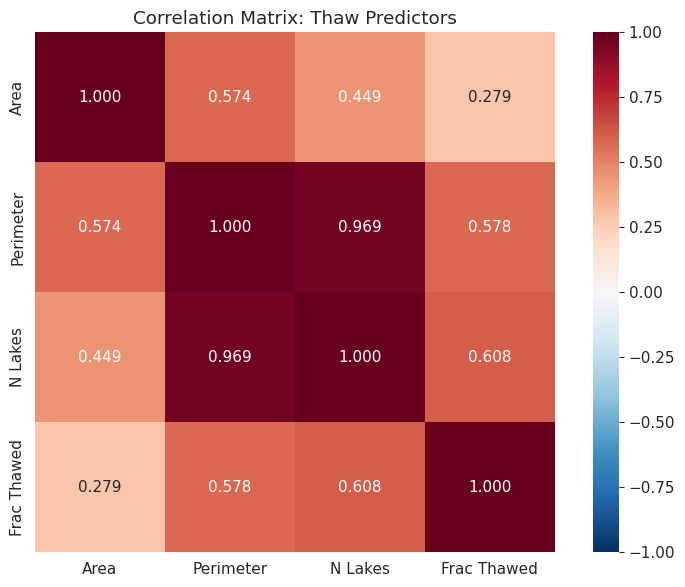


Saved: ch4_predictor_correlations.png

--- Variance Inflation Factor (VIF) ---
Testing collinearity when area and perimeter are both in model
       Variable     VIF
thawed_area_km2 1.49142
thawed_perim_km 1.49142

VIF Interpretation:
  VIF = 1: No correlation with other predictors
  VIF > 5: Moderate collinearity (caution)
  VIF > 10: Severe collinearity (problematic)

✓ VIF = 1.5 - collinearity is acceptable.


In [13]:
# Part 6A: Collinearity Diagnostics
print("="*70)
print("PART 6A: COLLINEARITY DIAGNOSTICS")
print("="*70)

from statsmodels.stats.outliers_influence import variance_inflation_factor

if len(panel_df) == 0 or panel_df['ch4_ppb'].notna().sum() < 100:
    print("\nInsufficient data for collinearity diagnostics.")
else:
    # Use reg_data from earlier (already filtered to non-null CH4)
    
    # ========================================================================
    # Correlation Matrix
    # ========================================================================
    print("\n--- Correlation Matrix ---")
    corr_vars = ['thawed_area_km2', 'thawed_perim_km', 'n_thawed_lakes', 'frac_thawed']
    corr_matrix = reg_data[corr_vars].corr()
    
    print("\nPearson correlations between predictors:")
    print(corr_matrix.round(3).to_string())
    
    # Key correlations
    print(f"\nKey pairwise correlations:")
    print(f"  Area vs Perimeter:    r = {corr_matrix.loc['thawed_area_km2', 'thawed_perim_km']:.3f}")
    print(f"  Perimeter vs N_lakes: r = {corr_matrix.loc['thawed_perim_km', 'n_thawed_lakes']:.3f}")
    print(f"  Area vs N_lakes:      r = {corr_matrix.loc['thawed_area_km2', 'n_thawed_lakes']:.3f}")
    
    # Plot correlation heatmap
    fig, ax = plt.subplots(figsize=(8, 6))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, ax=ax, square=True,
                xticklabels=['Area', 'Perimeter', 'N Lakes', 'Frac Thawed'],
                yticklabels=['Area', 'Perimeter', 'N Lakes', 'Frac Thawed'])
    ax.set_title('Correlation Matrix: Thaw Predictors')
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/working/ch4_predictor_correlations.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nSaved: ch4_predictor_correlations.png")
    
    # ========================================================================
    # Variance Inflation Factor (VIF)
    # ========================================================================
    print("\n--- Variance Inflation Factor (VIF) ---")
    print("Testing collinearity when area and perimeter are both in model")
    
    # Add constant for VIF calculation
    from statsmodels.tools import add_constant
    X_vif = reg_data[['thawed_area_km2', 'thawed_perim_km']].copy()
    X_vif = add_constant(X_vif)
    
    # Calculate VIF for each predictor
    vif_data = []
    for i, col in enumerate(X_vif.columns):
        if col != 'const':
            vif = variance_inflation_factor(X_vif.values, i)
            vif_data.append({'Variable': col, 'VIF': vif})
    
    vif_df = pd.DataFrame(vif_data)
    print(vif_df.to_string(index=False))
    
    print("\nVIF Interpretation:")
    print("  VIF = 1: No correlation with other predictors")
    print("  VIF > 5: Moderate collinearity (caution)")
    print("  VIF > 10: Severe collinearity (problematic)")
    
    max_vif = vif_df['VIF'].max()
    if max_vif > 10:
        print(f"\n⚠️  WARNING: VIF = {max_vif:.1f} indicates severe collinearity!")
        print("   Area and perimeter are highly correlated - interpret Model 3 with caution.")
    elif max_vif > 5:
        print(f"\n⚠️  CAUTION: VIF = {max_vif:.1f} indicates moderate collinearity.")
    else:
        print(f"\n✓ VIF = {max_vif:.1f} - collinearity is acceptable.")

In [14]:
# Part 6B: Competing Hypothesis Models
print("="*70)
print("PART 6B: COMPETING HYPOTHESIS MODELS")
print("="*70)

# Initialize results storage for all diagnostic models
diagnostic_results = []

if len(panel_df) == 0 or panel_df['ch4_ppb'].notna().sum() < 100:
    print("\nInsufficient data for competing hypothesis tests.")
else:
    # ========================================================================
    # Model A: n_thawed_lakes (Count Effect)
    # Hypothesis: More lakes = more CH4 (regardless of size/perimeter)
    # ========================================================================
    print(f"\n{'='*70}")
    print("MODEL A: Count Effect (n_thawed_lakes)")
    print("Hypothesis: More lakes → more emission sources → more CH4")
    print(f"{'='*70}")
    
    mod_A = PanelOLS(
        reg_data['ch4_ppb'],
        reg_data[['n_thawed_lakes']],
        entity_effects=True,
        time_effects=True
    )
    results_A = mod_A.fit(cov_type='clustered', cluster_entity=True)
    
    beta_A = results_A.params['n_thawed_lakes']
    se_A = results_A.std_errors['n_thawed_lakes']
    pval_A = results_A.pvalues['n_thawed_lakes']
    r2_A = results_A.rsquared_within
    
    print(f"\nResult:")
    print(f"  β(n_thawed_lakes) = {beta_A:.4f} ppb per lake")
    print(f"  SE = {se_A:.4f}, p = {pval_A:.4f}")
    print(f"  95% CI: [{beta_A - 1.96*se_A:.4f}, {beta_A + 1.96*se_A:.4f}]")
    print(f"  R² within: {r2_A:.4f}")
    
    diagnostic_results.append({
        'model': 'A', 'predictor': 'n_thawed_lakes', 
        'beta': beta_A, 'se': se_A, 'pval': pval_A, 'r2_within': r2_A,
        'interpretation': 'Count effect'
    })
    # ========================================================================
    # Model B: mean_sdi_thawed (Complexity Effect)
    # Hypothesis: Complex-shaped lakes emit more CH4
    # ========================================================================
    print(f"\n{'='*70}")
    print("MODEL B: Complexity Effect (mean_sdi_thawed)")
    print("Hypothesis: Complex-shaped lakes (high SDI) → more CH4")
    print(f"{'='*70}")
    
    # Filter to observations with mean_sdi_thawed (n_thawed > 0)
    reg_data_sdi = reg_data[reg_data['mean_sdi_thawed'].notna()].copy()
    print(f"Observations with mean_sdi_thawed: {len(reg_data_sdi):,}")
    
    if len(reg_data_sdi) >= 100:
        mod_B = PanelOLS(
            reg_data_sdi['ch4_ppb'],
            reg_data_sdi[['mean_sdi_thawed']],
            entity_effects=True,
            time_effects=True
        )
        results_B = mod_B.fit(cov_type='clustered', cluster_entity=True)
        
        beta_B = results_B.params['mean_sdi_thawed']
        se_B = results_B.std_errors['mean_sdi_thawed']
        pval_B = results_B.pvalues['mean_sdi_thawed']
        r2_B = results_B.rsquared_within
        
        print(f"\nResult:")
        print(f"  β(mean_sdi_thawed) = {beta_B:.4f} ppb per unit SDI")
        print(f"  SE = {se_B:.4f}, p = {pval_B:.4f}")
        print(f"  95% CI: [{beta_B - 1.96*se_B:.4f}, {beta_B + 1.96*se_B:.4f}]")
        print(f"  R² within: {r2_B:.4f}")
        
        diagnostic_results.append({
            'model': 'B', 'predictor': 'mean_sdi_thawed', 
            'beta': beta_B, 'se': se_B, 'pval': pval_B, 'r2_within': r2_B,
            'interpretation': 'Complexity effect'
        })
    else:
        print("Insufficient observations with SDI data.")
        results_B = None
    # ========================================================================
    # Model C: thawed_perim + n_thawed_lakes
    # Test: Does perimeter effect survive after controlling for count?
    # ========================================================================
    print(f"\n{'='*70}")
    print("MODEL C: Perimeter Controlling for Count")
    print("Test: Is perimeter effect real, or just a count effect in disguise?")
    print(f"{'='*70}")
    
    mod_C = PanelOLS(
        reg_data['ch4_ppb'],
        reg_data[['thawed_perim_km', 'n_thawed_lakes']],
        entity_effects=True,
        time_effects=True
    )
    results_C = mod_C.fit(cov_type='clustered', cluster_entity=True)
    print(results_C.summary)
    
    beta_C_perim = results_C.params['thawed_perim_km']
    se_C_perim = results_C.std_errors['thawed_perim_km']
    pval_C_perim = results_C.pvalues['thawed_perim_km']
    
    beta_C_count = results_C.params['n_thawed_lakes']
    se_C_count = results_C.std_errors['n_thawed_lakes']
    pval_C_count = results_C.pvalues['n_thawed_lakes']
    
    r2_C = results_C.rsquared_within
    
    print(f"\nKey Interpretation:")
    if pval_C_perim < 0.05 and pval_C_count >= 0.05:
        print("  → Perimeter significant, count NOT significant")
        print("  → TRUE SHORELINE EFFECT (not just count)")
    elif pval_C_perim >= 0.05 and pval_C_count < 0.05:
        print("  → Count significant, perimeter NOT significant")
        print("  → PERIMETER EFFECT WAS ACTUALLY A COUNT EFFECT")
    elif pval_C_perim < 0.05 and pval_C_count < 0.05:
        print("  → Both significant")
        print("  → Both shoreline and count effects present")
    else:
        print("  → Neither significant when both included")
    
    diagnostic_results.append({
        'model': 'C', 'predictor': 'thawed_perim_km (ctrl count)', 
        'beta': beta_C_perim, 'se': se_C_perim, 'pval': pval_C_perim, 'r2_within': r2_C,
        'interpretation': 'Perim controlling for count'
    })
    # ========================================================================
    # Model D: thawed_area + n_thawed_lakes
    # Test: Does area effect appear when controlling for count?
    # ========================================================================
    print(f"\n{'='*70}")
    print("MODEL D: Area Controlling for Count")
    print("Test: Does area become significant when controlling for lake count?")
    print(f"{'='*70}")
    
    mod_D = PanelOLS(
        reg_data['ch4_ppb'],
        reg_data[['thawed_area_km2', 'n_thawed_lakes']],
        entity_effects=True,
        time_effects=True
    )
    results_D = mod_D.fit(cov_type='clustered', cluster_entity=True)
    print(results_D.summary)
    
    beta_D_area = results_D.params['thawed_area_km2']
    se_D_area = results_D.std_errors['thawed_area_km2']
    pval_D_area = results_D.pvalues['thawed_area_km2']
    r2_D = results_D.rsquared_within
    
    diagnostic_results.append({
        'model': 'D', 'predictor': 'thawed_area_km2 (ctrl count)', 
        'beta': beta_D_area, 'se': se_D_area, 'pval': pval_D_area, 'r2_within': r2_D,
        'interpretation': 'Area controlling for count'
    })

PART 6B: COMPETING HYPOTHESIS MODELS

MODEL A: Count Effect (n_thawed_lakes)
Hypothesis: More lakes → more emission sources → more CH4



Result:
  β(n_thawed_lakes) = 0.0149 ppb per lake
  SE = 0.0040, p = 0.0002
  95% CI: [0.0070, 0.0228]
  R² within: -0.0113

MODEL B: Complexity Effect (mean_sdi_thawed)
Hypothesis: Complex-shaped lakes (high SDI) → more CH4
Observations with mean_sdi_thawed: 17,806



Result:
  β(mean_sdi_thawed) = 0.2740 ppb per unit SDI
  SE = 1.0766, p = 0.7991
  95% CI: [-1.8362, 2.3842]
  R² within: 0.0001

MODEL C: Perimeter Controlling for Count
Test: Is perimeter effect real, or just a count effect in disguise?


                          PanelOLS Estimation Summary                           
Dep. Variable:                ch4_ppb   R-squared:                        0.0006
Estimator:                   PanelOLS   R-squared (Between):              0.0004
No. Observations:               31953   R-squared (Within):              -0.0114
Date:                Sat, Jun 27 2026   R-squared (Overall):              0.0004
Time:                        05:27:38   Log-likelihood                -1.279e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      8.7101
Entities:                         508   P-value                           0.0002
Avg Obs:                       62.900   Distribution:                 F(2,31313)
Min Obs:                       12.000                                           
Max Obs:                       101.00   F-statistic (robust):             7.7078
                            

                          PanelOLS Estimation Summary                           
Dep. Variable:                ch4_ppb   R-squared:                        0.0005
Estimator:                   PanelOLS   R-squared (Between):              0.0004
No. Observations:               31953   R-squared (Within):              -0.0113
Date:                Sat, Jun 27 2026   R-squared (Overall):              0.0003
Time:                        05:27:38   Log-likelihood                -1.279e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      7.7859
Entities:                         508   P-value                           0.0004
Avg Obs:                       62.900   Distribution:                 F(2,31313)
Min Obs:                       12.000                                           
Max Obs:                       101.00   F-statistic (robust):             7.0611
                            

In [15]:
# Part 6C: Temporal Autocorrelation
print("="*70)
print("PART 6C: TEMPORAL AUTOCORRELATION (DURBIN-WATSON)")
print("="*70)

from statsmodels.stats.stattools import durbin_watson

if len(panel_df) == 0 or panel_df['ch4_ppb'].notna().sum() < 100:
    print("\nInsufficient data for autocorrelation test.")
else:
    # Extract residuals from Model 2 (perimeter model)
    if 'results2' in dir() and results2 is not None:
        residuals = results2.resids
        
        # Durbin-Watson test on pooled residuals
        dw_stat = durbin_watson(residuals.values)
        
        print(f"\nDurbin-Watson statistic: {dw_stat:.3f}")
        print("\nInterpretation:")
        print("  DW ≈ 2.0: No autocorrelation (ideal)")
        print("  DW < 1.5: Positive autocorrelation (concern)")
        print("  DW > 2.5: Negative autocorrelation")
        
        if dw_stat < 1.5:
            print(f"\n⚠️  WARNING: DW = {dw_stat:.3f} indicates POSITIVE AUTOCORRELATION")
            print("   Residuals are correlated across time within pixels.")
            print("   Standard errors may be underestimated.")
            print("   Consider: Newey-West SEs, or including lagged dependent variable.")
        elif dw_stat > 2.5:
            print(f"\n⚠️  WARNING: DW = {dw_stat:.3f} indicates NEGATIVE AUTOCORRELATION")
        else:
            print(f"\n✓ DW = {dw_stat:.3f} - No significant autocorrelation detected.")
        
        # Additional: Check autocorrelation by lag
        print("\n--- Residual Autocorrelation by Lag ---")
        resid_df = residuals.reset_index()
        resid_df.columns = ['cell_id', 'time_id', 'resid']
        resid_df = resid_df.sort_values(['cell_id', 'time_id'])
        
        # Compute autocorrelation at lag 1 within each pixel
        resid_df['resid_lag1'] = resid_df.groupby('cell_id')['resid'].shift(1)
        valid_lags = resid_df.dropna()
        
        if len(valid_lags) > 100:
            lag1_corr, lag1_pval = stats.pearsonr(valid_lags['resid'], valid_lags['resid_lag1'])
            print(f"Lag-1 autocorrelation: r = {lag1_corr:.3f}, p = {lag1_pval:.4f}")
            
            if lag1_pval < 0.05:
                print("  → Significant lag-1 autocorrelation detected.")
            else:
                print("  → No significant lag-1 autocorrelation.")
    else:
        print("Model 2 results not available for residual analysis.")

PART 6C: TEMPORAL AUTOCORRELATION (DURBIN-WATSON)

Durbin-Watson statistic: 0.576

Interpretation:
  DW ≈ 2.0: No autocorrelation (ideal)
  DW < 1.5: Positive autocorrelation (concern)
  DW > 2.5: Negative autocorrelation

⚠️  WARNING: DW = 0.576 indicates POSITIVE AUTOCORRELATION
   Residuals are correlated across time within pixels.
   Standard errors may be underestimated.
   Consider: Newey-West SEs, or including lagged dependent variable.

--- Residual Autocorrelation by Lag ---
Lag-1 autocorrelation: r = -0.030, p = 0.0000
  → Significant lag-1 autocorrelation detected.


In [16]:
# Part 6C-2: Autocorrelation-Robust Standard Errors Comparison
print("="*70)
print("PART 6C-2: AUTOCORRELATION-ROBUST STANDARD ERRORS")
print("="*70)

# Compare Model A (n_thawed_lakes) with different SE estimators
# This shows how much temporal autocorrelation affects our inference

if len(reg_data) < 100:
    print("\nInsufficient data for SE comparison.")
else:
    from linearmodels.panel import PanelOLS
    
    # Set up Model A
    model_a = PanelOLS.from_formula(
        'ch4_ppb ~ n_thawed_lakes + EntityEffects + TimeEffects',
        data=reg_data
    )
    
    # 1. Clustered SE (original) - cluster by entity (pixel)
    res_clustered = model_a.fit(cov_type='clustered', cluster_entity=True)
    
    # 2. Driscoll-Kraay HAC (Bartlett kernel, default bandwidth)
    # This is similar to Newey-West for panels
    res_dk_default = model_a.fit(cov_type='kernel')
    
    # 3. Driscoll-Kraay with explicit Bartlett kernel and bandwidth=3
    res_dk_bw3 = model_a.fit(cov_type='kernel', kernel='bartlett', bandwidth=3)
    
    # 4. Driscoll-Kraay with bandwidth=5 (more conservative)
    res_dk_bw5 = model_a.fit(cov_type='kernel', kernel='bartlett', bandwidth=5)
    
    # 5. Two-way clustering (entity and time)
    res_twoway = model_a.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)
    
    # Extract n_thawed_lakes results
    var = 'n_thawed_lakes'
    
    print("\nModel A: ch4_ppb ~ n_thawed_lakes + EntityEffects + TimeEffects")
    print("\nComparing Standard Error Estimators:")
    print("-" * 80)
    print(f"{'SE Type':<35} {'β':>12} {'SE':>12} {'t':>10} {'p-value':>12}")
    print("-" * 80)
    
    results_list = [
        ('Clustered (entity)', res_clustered),
        ('Two-way clustered (entity+time)', res_twoway),
        ('Driscoll-Kraay (default bw)', res_dk_default),
        ('Driscoll-Kraay (bw=3)', res_dk_bw3),
        ('Driscoll-Kraay (bw=5)', res_dk_bw5),
    ]
    
    se_comparison = []
    for name, res in results_list:
        beta = res.params[var]
        se = res.std_errors[var]
        t = res.tstats[var]
        pval = res.pvalues[var]
        print(f"{name:<35} {beta:>12.6f} {se:>12.6f} {t:>10.3f} {pval:>12.6f}")
        se_comparison.append({'SE Type': name, 'beta': beta, 'SE': se, 't': t, 'p-value': pval})
    
    print("-" * 80)
    
    # Calculate SE inflation factor
    se_clustered = res_clustered.std_errors[var]
    print("\nSE Inflation Relative to Clustered:")
    for name, res in results_list[1:]:
        se = res.std_errors[var]
        inflation = se / se_clustered
        print(f"  {name}: {inflation:.2f}x")
    
    print("\n" + "="*70)
    print("INTERPRETATION")
    print("="*70)
    
    # Determine if count effect is robust
    p_clustered = res_clustered.pvalues[var]
    p_twoway = res_twoway.pvalues[var]
    p_dk = res_dk_bw5.pvalues[var]  # Most conservative
    
    print(f"\nOriginal clustered p-value: {p_clustered:.6f}")
    print(f"Two-way clustered p-value: {p_twoway:.6f}")
    print(f"Driscoll-Kraay (bw=5) p-value: {p_dk:.6f}")
    
    if p_dk < 0.05:
        print("\n→ COUNT EFFECT REMAINS SIGNIFICANT even with conservative HAC SEs.")
        print("  The autocorrelation inflates SEs but does not eliminate significance.")
    elif p_dk < 0.10:
        print("\n→ COUNT EFFECT BECOMES MARGINAL with conservative HAC SEs.")
        print("  Autocorrelation substantially weakens the inference.")
    else:
        print("\n→ COUNT EFFECT LOSES SIGNIFICANCE with conservative HAC SEs.")
        print("  The original result was driven by underestimated SEs.")
    
    print("\nNote: Driscoll-Kraay SEs are robust to both cross-sectional and")
    print("      temporal dependence, making them appropriate for this panel.")


PART 6C-2: AUTOCORRELATION-ROBUST STANDARD ERRORS



Model A: ch4_ppb ~ n_thawed_lakes + EntityEffects + TimeEffects

Comparing Standard Error Estimators:
--------------------------------------------------------------------------------
SE Type                                        β           SE          t      p-value
--------------------------------------------------------------------------------
Clustered (entity)                      0.014884     0.004016      3.706     0.000211


Two-way clustered (entity+time)         0.014884     0.011732      1.269     0.204589
Driscoll-Kraay (default bw)             0.014884     0.009135      1.629     0.103275
Driscoll-Kraay (bw=3)                   0.014884     0.009476      1.571     0.116248
Driscoll-Kraay (bw=5)                   0.014884     0.008861      1.680     0.093013
--------------------------------------------------------------------------------

SE Inflation Relative to Clustered:
  Two-way clustered (entity+time): 2.92x
  Driscoll-Kraay (default bw): 2.27x
  Driscoll-Kraay (bw=3): 2.36x
  Driscoll-Kraay (bw=5): 2.21x

INTERPRETATION

Original clustered p-value: 0.000211
Two-way clustered p-value: 0.204589
Driscoll-Kraay (bw=5) p-value: 0.093013

→ COUNT EFFECT BECOMES MARGINAL with conservative HAC SEs.
  Autocorrelation substantially weakens the inference.

Note: Driscoll-Kraay SEs are robust to both cross-sectional and
      temporal dependence, making them appropriate for this panel.


In [17]:
# Part 6D: Missing Data Analysis
print("="*70)
print("PART 6D: MISSING DATA ANALYSIS")
print("="*70)

if len(panel_df) == 0:
    print("\nNo panel data for missing data analysis.")
else:
    # Split into observed (CH4 present) vs missing (CH4 absent)
    observed = panel_df[panel_df['ch4_ppb'].notna()].copy()
    missing = panel_df[panel_df['ch4_ppb'].isna()].copy()
    
    print(f"\nObservations with CH4:    {len(observed):,} ({100*len(observed)/len(panel_df):.1f}%)")
    print(f"Observations without CH4: {len(missing):,} ({100*len(missing)/len(panel_df):.1f}%)")
    
    # Compare means of key variables between observed and missing
    test_vars = ['thawed_area_km2', 'thawed_perim_km', 'frac_thawed', 'n_thawed_lakes', 'week']
    
    print("\n--- T-Tests: Observed vs Missing CH4 Groups ---")
    print(f"{'Variable':<20} {'Mean (Obs)':<12} {'Mean (Miss)':<12} {'t-stat':<10} {'p-value':<10} {'Conclusion'}")
    print("-" * 90)
    
    missing_data_results = []
    for var in test_vars:
        obs_vals = observed[var].dropna()
        miss_vals = missing[var].dropna()
        
        if len(obs_vals) > 0 and len(miss_vals) > 0:
            t_stat, p_val = stats.ttest_ind(obs_vals, miss_vals)
            conclusion = "SYSTEMATIC" if p_val < 0.05 else "Random"
            
            print(f"{var:<20} {obs_vals.mean():<12.2f} {miss_vals.mean():<12.2f} {t_stat:<10.2f} {p_val:<10.4f} {conclusion}")
            
            missing_data_results.append({
                'variable': var,
                'mean_observed': obs_vals.mean(),
                'mean_missing': miss_vals.mean(),
                't_stat': t_stat,
                'p_val': p_val,
                'systematic': p_val < 0.05
            })
    
    # Interpretation
    n_systematic = sum([r['systematic'] for r in missing_data_results])
    
    print("\n--- Interpretation ---")
    if n_systematic == 0:
        print("✓ Missing data appears RANDOM (MAR/MCAR)")
        print("  No significant differences between groups.")
        print("  Panel regression estimates should be unbiased.")
    else:
        print(f"⚠️  Missing data is SYSTEMATIC for {n_systematic}/{len(test_vars)} variables")
        systematic_vars = [r['variable'] for r in missing_data_results if r['systematic']]
        print(f"   Affected variables: {', '.join(systematic_vars)}")
        
        # Check if week is systematic (seasonal pattern)
        week_result = next((r for r in missing_data_results if r['variable'] == 'week'), None)
        if week_result and week_result['systematic']:
            print("\n   IMPORTANT: CH4 missingness is related to WEEK")
            print("   This suggests seasonal patterns in TROPOMI coverage.")
            print("   (e.g., cloud cover in summer, polar night in winter)")
            print("   Time fixed effects should absorb this, but interpret with caution.")

PART 6D: MISSING DATA ANALYSIS

Observations with CH4:    31,953 (34.8%)
Observations without CH4: 59,847 (65.2%)

--- T-Tests: Observed vs Missing CH4 Groups ---
Variable             Mean (Obs)   Mean (Miss)  t-stat     p-value    Conclusion
------------------------------------------------------------------------------------------
thawed_area_km2      5.45         12.34        -33.96     0.0000     SYSTEMATIC
thawed_perim_km      54.51        103.47       -63.63     0.0000     SYSTEMATIC
frac_thawed          0.49         0.67         -55.42     0.0000     SYSTEMATIC
n_thawed_lakes       22.07        38.54        -58.14     0.0000     SYSTEMATIC
week                 22.82        28.47        -81.25     0.0000     SYSTEMATIC

--- Interpretation ---
⚠️  Missing data is SYSTEMATIC for 5/5 variables
   Affected variables: thawed_area_km2, thawed_perim_km, frac_thawed, n_thawed_lakes, week

   IMPORTANT: CH4 missingness is related to WEEK
   This suggests seasonal patterns in TROPOMI covera

In [18]:
# Part 6E: Effect Size Plausibility
print("="*70)
print("PART 6E: EFFECT SIZE PLAUSIBILITY")
print("="*70)

if len(panel_df) == 0 or 'results2' not in dir() or results2 is None:
    print("\nInsufficient data for effect size analysis.")
else:
    # Get perimeter coefficient from Model 2
    beta_perim = results2.params['thawed_perim_km']
    
    # Report distribution of total_perim_km (static, when all lakes thawed)
    mean_total_perim = active_cells['total_lake_perim_km'].mean()
    std_total_perim = active_cells['total_lake_perim_km'].std()
    median_total_perim = active_cells['total_lake_perim_km'].median()
    
    print("\n--- Total Lake Perimeter per Pixel (when all lakes thawed) ---")
    print(f"  Mean:   {mean_total_perim:.1f} km")
    print(f"  Std:    {std_total_perim:.1f} km")
    print(f"  Median: {median_total_perim:.1f} km")
    print(f"  Range:  {active_cells['total_lake_perim_km'].min():.1f} - {active_cells['total_lake_perim_km'].max():.1f} km")
    
    # Calculate predicted CH4 increase from 0% to 100% thaw
    predicted_delta_mean = beta_perim * mean_total_perim
    predicted_delta_median = beta_perim * median_total_perim
    
    print(f"\n--- Predicted CH4 Increase (0% → 100% thaw) ---")
    print(f"  Using mean perimeter:   {predicted_delta_mean:.2f} ppb")
    print(f"  Using median perimeter: {predicted_delta_median:.2f} ppb")
    
    # Benchmarks
    # 1. Within-pixel CH4 standard deviation
    within_pixel_std = reg_data.reset_index().groupby('cell_id')['ch4_ppb'].std().mean()
    
    # 2. TROPOMI single-measurement precision (typical: 15-20 ppb)
    tropomi_precision = 17  # ppb, approximate
    
    # 3. Overall CH4 standard deviation
    overall_ch4_std = reg_data['ch4_ppb'].std()
    
    print(f"\n--- Comparison to Variability Benchmarks ---")
    print(f"  Predicted effect (0→100% thaw):  {predicted_delta_mean:.2f} ppb")
    print(f"  Within-pixel CH4 std dev:        {within_pixel_std:.2f} ppb")
    print(f"  Overall CH4 std dev:             {overall_ch4_std:.2f} ppb")
    print(f"  TROPOMI precision:               ~{tropomi_precision} ppb")
    
    # Effect as fraction of variability
    pct_within_std = 100 * abs(predicted_delta_mean) / within_pixel_std if within_pixel_std > 0 else 0
    pct_tropomi = 100 * abs(predicted_delta_mean) / tropomi_precision
    
    print(f"\n--- Effect Size Assessment ---")
    print(f"  Effect as % of within-pixel std: {pct_within_std:.1f}%")
    print(f"  Effect as % of TROPOMI precision: {pct_tropomi:.1f}%")
    
    print("\n--- Plausibility Interpretation ---")
    if abs(predicted_delta_mean) < tropomi_precision * 0.5:
        print(f"⚠️  Effect ({predicted_delta_mean:.2f} ppb) is < 50% of TROPOMI precision ({tropomi_precision} ppb)")
        print("   Effect may be too small to reliably detect with this instrument.")
        print("   Statistical significance could be spurious.")
    elif abs(predicted_delta_mean) < within_pixel_std:
        print(f"✓ Effect ({predicted_delta_mean:.2f} ppb) is detectable but small")
        print(f"   Effect is {pct_within_std:.1f}% of within-pixel variation.")
        print("   This is a modest but potentially real signal.")
    else:
        print(f"✓ Effect ({predicted_delta_mean:.2f} ppb) is substantial")
        print(f"   Effect exceeds typical within-pixel variation.")
    
    # Physical plausibility check
    print(f"\n--- Physical Plausibility ---")
    ppb_per_km = beta_perim
    print(f"  Each 1 km of thawed shoreline → {ppb_per_km:.4f} ppb CH4 increase")
    print(f"  For context: 1 km shoreline with 1m littoral zone = 0.001 km² area")
    print(f"  This corresponds to {ppb_per_km / 0.001:.1f} ppb per km² of littoral area")

PART 6E: EFFECT SIZE PLAUSIBILITY

--- Total Lake Perimeter per Pixel (when all lakes thawed) ---
  Mean:   149.1 km
  Std:    121.0 km
  Median: 117.1 km
  Range:  4.2 - 582.4 km

--- Predicted CH4 Increase (0% → 100% thaw) ---
  Using mean perimeter:   0.68 ppb
  Using median perimeter: 0.53 ppb

--- Comparison to Variability Benchmarks ---
  Predicted effect (0→100% thaw):  0.68 ppb
  Within-pixel CH4 std dev:        26.55 ppb
  Overall CH4 std dev:             27.53 ppb
  TROPOMI precision:               ~17 ppb

--- Effect Size Assessment ---
  Effect as % of within-pixel std: 2.6%
  Effect as % of TROPOMI precision: 4.0%

--- Plausibility Interpretation ---
⚠️  Effect (0.68 ppb) is < 50% of TROPOMI precision (17 ppb)
   Effect may be too small to reliably detect with this instrument.
   Statistical significance could be spurious.

--- Physical Plausibility ---
  Each 1 km of thawed shoreline → 0.0046 ppb CH4 increase
  For context: 1 km shoreline with 1m littoral zone = 0.001 km²

In [19]:
# Part 6 Summary: Comprehensive Model Comparison Table
print("="*70)
print("PART 6 SUMMARY: MODEL COMPARISON TABLE")
print("="*70)

# Build comprehensive results table
all_results = []

# Add main models (1, 2, 3) from Part 5
if 'results1' in dir() and results1 is not None:
    all_results.append({
        'Model': '1', 'Predictor(s)': 'thawed_area',
        'beta': results1.params['thawed_area_km2'],
        'SE': results1.std_errors['thawed_area_km2'],
        'p-value': results1.pvalues['thawed_area_km2'],
        'R2_within': results1.rsquared_within,
        'Interpretation': 'Area alone'
    })

if 'results2' in dir() and results2 is not None:
    all_results.append({
        'Model': '2', 'Predictor(s)': 'thawed_perim',
        'beta': results2.params['thawed_perim_km'],
        'SE': results2.std_errors['thawed_perim_km'],
        'p-value': results2.pvalues['thawed_perim_km'],
        'R2_within': results2.rsquared_within,
        'Interpretation': 'Perimeter alone'
    })

if 'results3' in dir() and results3 is not None:
    all_results.append({
        'Model': '3', 'Predictor(s)': 'area + perim',
        'beta': results3.params['thawed_perim_km'],  # Report perimeter coef
        'SE': results3.std_errors['thawed_perim_km'],
        'p-value': results3.pvalues['thawed_perim_km'],
        'R2_within': results3.rsquared_within,
        'Interpretation': 'Both (perim coef shown)'
    })

# Add diagnostic models (A, B, C, D) from Part 6B
if 'diagnostic_results' in dir() and diagnostic_results:
    for r in diagnostic_results:
        all_results.append({
            'Model': r['model'], 'Predictor(s)': r['predictor'],
            'beta': r['beta'], 'SE': r['se'], 'p-value': r['pval'],
            'R2_within': r['r2_within'], 'Interpretation': r['interpretation']
        })

if all_results:
    summary_df = pd.DataFrame(all_results)
    
    # Format for display
    print("\n" + "="*100)
    print(f"{'Model':<6} {'Predictor(s)':<30} {'β':<12} {'SE':<10} {'p-value':<10} {'R² within':<12} {'Interpretation'}")
    print("="*100)
    
    for _, row in summary_df.iterrows():
        sig = '***' if row['p-value'] < 0.001 else '**' if row['p-value'] < 0.01 else '*' if row['p-value'] < 0.05 else ''
        print(f"{row['Model']:<6} {row['Predictor(s)']:<30} {row['beta']:<12.4f} {row['SE']:<10.4f} {row['p-value']:<10.4f} {row['R2_within']:<12.4f} {row['Interpretation']}{sig}")
    
    print("="*100)
    print("Significance: *** p<0.001, ** p<0.01, * p<0.05")
    
    # Key conclusions
    print("\n" + "="*70)
    print("KEY DIAGNOSTIC CONCLUSIONS")
    print("="*70)
    
    # 1. Is perimeter effect real or count effect?
    if 'results_C' in dir() and results_C is not None:
        pval_perim_ctrl = results_C.pvalues['thawed_perim_km']
        pval_count_ctrl = results_C.pvalues['n_thawed_lakes']
        
        print("\n1. IS PERIMETER EFFECT REAL OR JUST COUNT EFFECT?")
        if pval_perim_ctrl < 0.05:
            print(f"   → Perimeter remains significant (p={pval_perim_ctrl:.4f}) after controlling for count")
            print("   → Supports TRUE SHORELINE EFFECT hypothesis")
        else:
            print(f"   → Perimeter NOT significant (p={pval_perim_ctrl:.4f}) after controlling for count")
            print("   → Perimeter effect may be confounded with lake count")
    
    # 2. Collinearity assessment
    if 'vif_df' in dir():
        max_vif = vif_df['VIF'].max()
        print(f"\n2. COLLINEARITY ASSESSMENT")
        print(f"   → Max VIF = {max_vif:.1f} (>10 = severe)")
        if max_vif > 10:
            print("   → SEVERE collinearity between area and perimeter")
        elif max_vif > 5:
            print("   → MODERATE collinearity - interpret multi-predictor models with caution")
        else:
            print("   → Acceptable collinearity levels")
    
    # 3. Autocorrelation
    if 'dw_stat' in dir():
        print(f"\n3. TEMPORAL AUTOCORRELATION")
        print(f"   → Durbin-Watson = {dw_stat:.3f}")
        if dw_stat < 1.5:
            print("   → Positive autocorrelation detected - SEs may be underestimated")
        elif dw_stat > 2.5:
            print("   → Negative autocorrelation detected")
        else:
            print("   → No significant autocorrelation")
    
    # 4. Effect size
    if 'predicted_delta_mean' in dir():
        print(f"\n4. EFFECT SIZE PLAUSIBILITY")
        print(f"   → Predicted CH4 change (0→100% thaw): {predicted_delta_mean:.2f} ppb")
        print(f"   → TROPOMI precision: ~17 ppb")
        if abs(predicted_delta_mean) < 8.5:  # < 50% of precision
            print("   → Effect is SMALL relative to instrument precision")
        else:
            print("   → Effect is detectable with TROPOMI")
    
    # 5. Missing data
    if 'n_systematic' in dir():
        print(f"\n5. MISSING DATA PATTERN")
        if n_systematic == 0:
            print("   → Missing data appears RANDOM")
        else:
            print(f"   → Missing data is SYSTEMATIC for {n_systematic} variables")
    
    print("\n" + "="*70)
else:
    print("No model results available for summary table.")

PART 6 SUMMARY: MODEL COMPARISON TABLE

Model  Predictor(s)                   β            SE         p-value    R² within    Interpretation
1      thawed_area                    0.0048       0.0041     0.2375     -0.0009      Area alone
2      thawed_perim                   0.0046       0.0015     0.0023     -0.0087      Perimeter alone**
3      area + perim                   0.0051       0.0016     0.0016     -0.0090      Both (perim coef shown)**
A      n_thawed_lakes                 0.0149       0.0040     0.0002     -0.0113      Count effect***
B      mean_sdi_thawed                0.2740       1.0766     0.7991     0.0001       Complexity effect
C      thawed_perim_km (ctrl count)   -0.0058      0.0043     0.1804     -0.0114      Perim controlling for count
D      thawed_area_km2 (ctrl count)   -0.0012      0.0026     0.6472     -0.0113      Area controlling for count
Significance: *** p<0.001, ** p<0.01, * p<0.05

KEY DIAGNOSTIC CONCLUSIONS

1. IS PERIMETER EFFECT REAL OR JUST C

## Part 7: Visualization & Diagnostics

Generate publication-quality figures for the panel regression results.

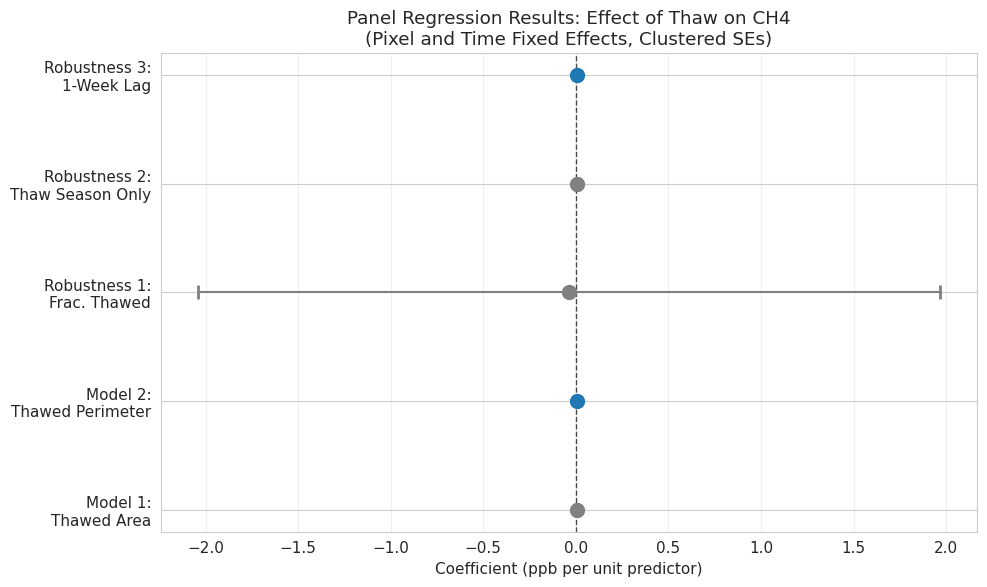

Saved: figures/supplementary/figS09_ch4_panel_regression.png


In [20]:
# Figure 1: Coefficient plot comparing models
if len(panel_df) > 0 and panel_df['ch4_ppb'].notna().sum() >= 100:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Collect results from all models
    model_results = []
    
    if 'results1' in dir() and results1 is not None:
        model_results.append({
            'model': 'Model 1:\nThawed Area',
            'beta': results1.params['thawed_area_km2'],
            'se': results1.std_errors['thawed_area_km2'],
            'predictor': 'thawed_area_km2'
        })
    
    if 'results2' in dir() and results2 is not None:
        model_results.append({
            'model': 'Model 2:\nThawed Perimeter',
            'beta': results2.params['thawed_perim_km'],
            'se': results2.std_errors['thawed_perim_km'],
            'predictor': 'thawed_perim_km'
        })
    
    if 'results_frac' in dir() and results_frac is not None:
        model_results.append({
            'model': 'Robustness 1:\nFrac. Thawed',
            'beta': results_frac.params['frac_thawed'],
            'se': results_frac.std_errors['frac_thawed'],
            'predictor': 'frac_thawed'
        })
    
    if 'results_season' in dir() and results_season is not None:
        model_results.append({
            'model': 'Robustness 2:\nThaw Season Only',
            'beta': results_season.params['thawed_area_km2'],
            'se': results_season.std_errors['thawed_area_km2'],
            'predictor': 'thawed_area_km2'
        })
    
    if 'results_lag' in dir() and results_lag is not None:
        model_results.append({
            'model': 'Robustness 3:\n1-Week Lag',
            'beta': results_lag.params['thawed_area_lag1'],
            'se': results_lag.std_errors['thawed_area_lag1'],
            'predictor': 'thawed_area_lag1'
        })
    
    if model_results:
        results_summary = pd.DataFrame(model_results)
        
        # Plot
        y_pos = range(len(results_summary))
        
        for i, row in results_summary.iterrows():
            ci_low = row['beta'] - 1.96 * row['se']
            ci_high = row['beta'] + 1.96 * row['se']
            
            # Color based on significance
            color = 'tab:blue' if abs(row['beta']) > 1.96 * row['se'] else 'gray'
            
            ax.errorbar(row['beta'], i, xerr=1.96 * row['se'],
                       fmt='o', color=color, capsize=5, capthick=2, markersize=10)
        
        ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.7)
        ax.set_yticks(range(len(results_summary)))
        ax.set_yticklabels(results_summary['model'])
        ax.set_xlabel('Coefficient (ppb per unit predictor)')
        ax.set_title('Panel Regression Results: Effect of Thaw on CH4\n(Pixel and Time Fixed Effects, Clustered SEs)')
        ax.grid(True, alpha=0.3, axis='x')
        
        plt.tight_layout()
        plt.savefig(f'{FIGURES_DIR}/supplementary/figS09_ch4_panel_regression.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("Saved: figures/supplementary/figS09_ch4_panel_regression.png")
    else:
        print("No model results available for plotting.")
else:
    print("Insufficient data for coefficient plot.")

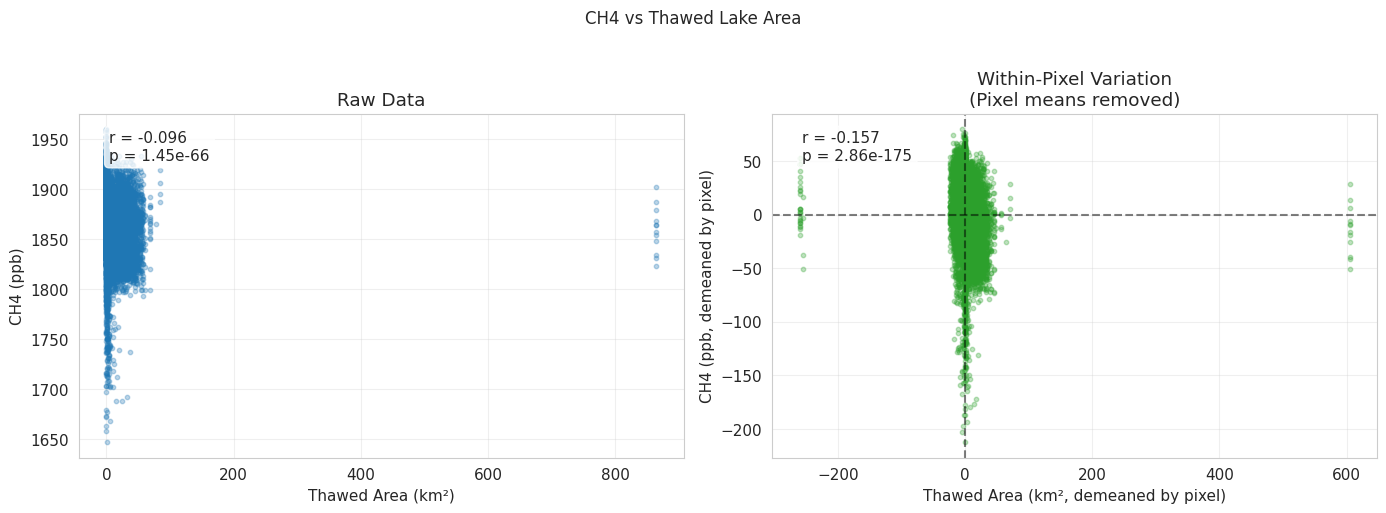

Saved: figures/supplementary/figS11_ch4_thaw_scatter.png


In [21]:
# Figure 2: CH4 vs Thawed Area scatter (residualized)
if len(panel_df) > 0 and panel_df['ch4_ppb'].notna().sum() >= 100:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Get residualized data (demean by cell and time)
    reg_data_plot = panel_df[panel_df['ch4_ppb'].notna()].copy()
    
    # Simple demeaning for visualization
    reg_data_plot['ch4_demeaned'] = reg_data_plot.groupby('cell_id')['ch4_ppb'].transform(lambda x: x - x.mean())
    reg_data_plot['thaw_demeaned'] = reg_data_plot.groupby('cell_id')['thawed_area_km2'].transform(lambda x: x - x.mean())
    
    # Panel A: Raw scatter
    ax = axes[0]
    ax.scatter(reg_data_plot['thawed_area_km2'], reg_data_plot['ch4_ppb'], 
               alpha=0.3, s=10, c='tab:blue')
    ax.set_xlabel('Thawed Area (km²)')
    ax.set_ylabel('CH4 (ppb)')
    ax.set_title('Raw Data')
    ax.grid(True, alpha=0.3)
    
    # Add correlation
    valid = reg_data_plot[['thawed_area_km2', 'ch4_ppb']].dropna()
    r, p = stats.pearsonr(valid['thawed_area_km2'], valid['ch4_ppb'])
    ax.text(0.05, 0.95, f'r = {r:.3f}\np = {p:.2e}', transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Panel B: Within-pixel variation (demeaned)
    ax = axes[1]
    ax.scatter(reg_data_plot['thaw_demeaned'], reg_data_plot['ch4_demeaned'], 
               alpha=0.3, s=10, c='tab:green')
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax.axvline(x=0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Thawed Area (km², demeaned by pixel)')
    ax.set_ylabel('CH4 (ppb, demeaned by pixel)')
    ax.set_title('Within-Pixel Variation\n(Pixel means removed)')
    ax.grid(True, alpha=0.3)
    
    # Add correlation
    valid = reg_data_plot[['thaw_demeaned', 'ch4_demeaned']].dropna()
    r, p = stats.pearsonr(valid['thaw_demeaned'], valid['ch4_demeaned'])
    ax.text(0.05, 0.95, f'r = {r:.3f}\np = {p:.2e}', transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.suptitle('CH4 vs Thawed Lake Area', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/supplementary/figS11_ch4_thaw_scatter.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: figures/supplementary/figS11_ch4_thaw_scatter.png")
else:
    print("Insufficient data for scatter plots.")

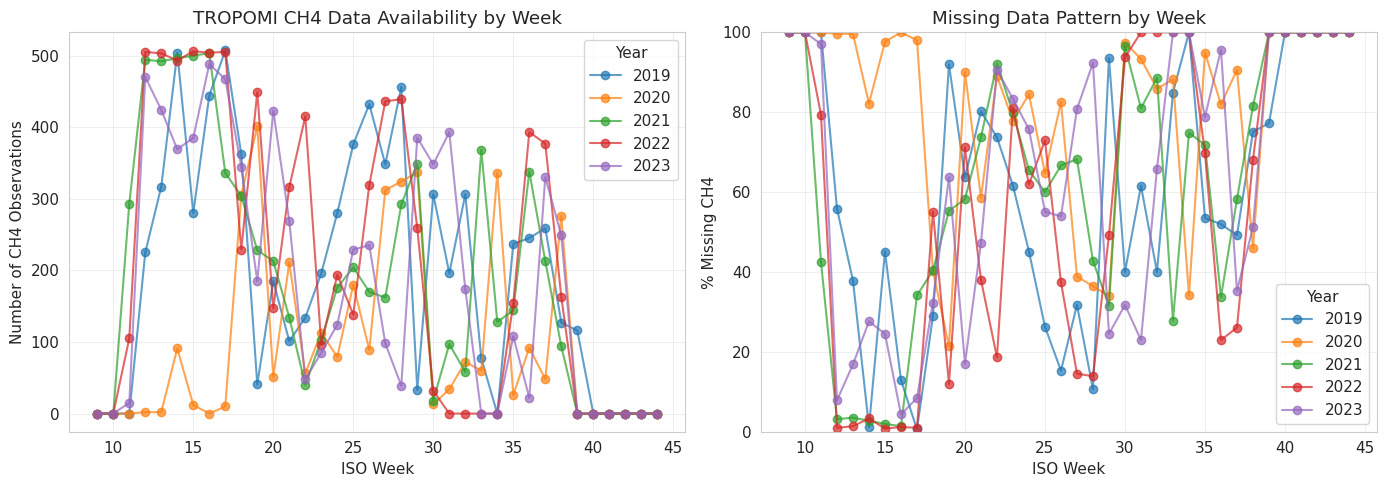

Saved: figures/supplementary/figS10_ch4_data_coverage.png


In [22]:
# Figure 3: CH4 data coverage heatmap
if len(panel_df) > 0:
    # Create coverage matrix
    coverage = panel_df.pivot_table(
        index='cell_id',
        columns=['year', 'week'],
        values='ch4_ppb',
        aggfunc='count'
    ).fillna(0)
    
    # Summarize coverage by week
    week_coverage = panel_df.groupby(['year', 'week']).agg({
        'ch4_ppb': lambda x: x.notna().sum(),
        'cell_id': 'nunique'
    }).reset_index()
    week_coverage.columns = ['year', 'week', 'n_obs', 'n_cells']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Panel A: Coverage by week over all years
    ax = axes[0]
    for year in YEARS:
        year_data = week_coverage[week_coverage['year'] == year]
        ax.plot(year_data['week'], year_data['n_obs'], 'o-', label=str(year), alpha=0.7)
    
    ax.set_xlabel('ISO Week')
    ax.set_ylabel('Number of CH4 Observations')
    ax.set_title('TROPOMI CH4 Data Availability by Week')
    ax.legend(title='Year')
    ax.grid(True, alpha=0.3)
    
    # Panel B: Missing data pattern
    ax = axes[1]
    missing_pct = panel_df.groupby(['year', 'week'])['ch4_ppb'].apply(lambda x: 100 * x.isna().mean())
    missing_df = missing_pct.reset_index()
    missing_df.columns = ['year', 'week', 'pct_missing']
    
    for year in YEARS:
        year_data = missing_df[missing_df['year'] == year]
        ax.plot(year_data['week'], year_data['pct_missing'], 'o-', label=str(year), alpha=0.7)
    
    ax.set_xlabel('ISO Week')
    ax.set_ylabel('% Missing CH4')
    ax.set_title('Missing Data Pattern by Week')
    ax.legend(title='Year')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 100)
    
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/supplementary/figS10_ch4_data_coverage.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: figures/supplementary/figS10_ch4_data_coverage.png")
else:
    print("No panel data for coverage plot.")

## Part 8: Export Results

Export panel dataset and regression results to GCS.

In [23]:
# Export panel dataset
print("Exporting results...")

if len(panel_df) == 0:
    print("No panel data to export.")
else:
    # Export panel dataset
    export_cols = [
        'cell_id', 'year', 'week', 'doy', 'date',
        'ch4_ppb',
        'thawed_area_km2', 'thawed_perim_km', 'frac_thawed', 'n_thawed_lakes',
        'mean_sdi_thawed',  # Added for diagnostic analysis
        'total_area_km2', 'total_perim_km', 'n_lakes',
        'lat_center', 'lon_center'
    ]
    
    # Filter to available columns
    available_cols = [c for c in export_cols if c in panel_df.columns]
    panel_export = panel_df[available_cols].copy()
    
    # Convert date to string for CSV
    if 'date' in panel_export.columns:
        panel_export['date'] = panel_export['date'].astype(str)
    
    panel_path = f'{RESULTS_GCS}/ch4_panel_data_weekly_2019-2023.csv'
    panel_export.to_csv(panel_path, index=False)
    print(f"  Exported: {panel_path}")
    print(f"  Rows: {len(panel_export):,}")

# Export regression summary (including diagnostic models)
if 'all_results' in dir() and all_results:
    results_path = f'{RESULTS_GCS}/ch4_panel_regression_summary.csv'
    pd.DataFrame(all_results).to_csv(results_path, index=False)
    print(f"  Exported: {results_path}")

print("\nExport complete!")

Exporting results...


  Exported: gs://wustl-eeps-geospatial/thermokarst_lakes/results/ch4_panel_data_weekly_2019-2023.csv
  Rows: 91,800
  Exported: gs://wustl-eeps-geospatial/thermokarst_lakes/results/ch4_panel_regression_summary.csv

Export complete!


## Summary

This notebook analyzed the relationship between TROPOMI CH4 column concentrations and cumulative lake thaw on Alaska's North Slope using panel regression with fixed effects.

**Scientific Question:** Does lake ice-off timing predict TROPOMI methane concentrations?

**Approach:**
- Weekly temporal resolution (ISO weeks 9-44, ~35 weeks Mar-Oct)
- Panel regression: CH4_it = β₁(thawed_area_it) + pixel_FE_i + week_FE_t + ε_it
- TROPOMI QA filtering: qa_value > 0.5
- Clustered standard errors by pixel

**Key Tests:**
1. **Model 1:** Thawed area as sole predictor
2. **Model 2:** Thawed perimeter as sole predictor
3. **Model 3:** Both area and perimeter
4. **Robustness 1:** Fractional thaw (0-1 scale)
5. **Robustness 2:** Thaw season only (DOY 120-220)
6. **Robustness 3:** 1-week lagged effects

**Output Files:**
- `ch4_panel_data_weekly_2019-2023.csv`: Full panel dataset
- `ch4_panel_regression_summary.csv`: Model coefficients and standard errors

**Figures Generated:**
- `ch4_analysis_grid.png`: Study area grid with lake density
- `ch4_thaw_progression.png`: Cumulative thaw curves by year
- `ch4_panel_regression_results.png`: Coefficient plot comparing models
- `ch4_thaw_scatter.png`: CH4 vs thawed area (raw and demeaned)
- `ch4_data_coverage.png`: TROPOMI data availability patterns